# Orbital Debris Database: Exploring the Landscape

**Database:** orbital_debris.db (SQLite)  
**Docs:** See the quick reports in notebook 04 and the data dictionary in `docs/schema` for full table and field details.

**Goal:** Find patterns, outliers, and follow-up questions in the orbital debris database to guide later analysis and charts.

**Process:**
- Define the question and the fields needed to answer it.
- Use SQL to pull the data and pandas to help prepare and analyze it.
- Make simple charts or tables to see what stands out.

### Why this notebook?
This notebook uses the cleaned, joined database for targeted exploration. It is meant for testing questions, checking patterns, and saving useful findings for later notebooks.

### What we do here
1. **Test questions:** Use SQL and pandas to check trends, outliers, and ideas.
2. **Make visuals:** Build quick charts to see what matters.
3. **Save findings:** Keep useful queries, charts, and notes for later work.

*For table structure, nulls, and sample data, see the end of notebook 04 and the data dictionary.*

In [1]:
import pandas as pd
import seaborn as sns
import sqlite3 as sql
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

sns.set_palette('colorblind')

plt.rcParams.update({
    "grid.alpha": 0.3,
    "axes.facecolor": "#333333",
    "figure.facecolor": "#333333",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "#333333",
    "legend.edgecolor": "white"
})

orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')

# Global configuration variables
MAX_TOP = 15

# colormap output for reference
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

**Note:** Notebook 04 has the quick reports for every table. Use it for table structure, nulls, and sample data. Use `docs/schema` for field definitions. This notebook's focus is exploration.

## Decoupling Point in Orbital Growth

Find when the growth of orbital objects changed from a steadier pattern to a much faster one, and show how the mix of object types changed over time. This helps show when crowding in orbit started to speed up.

**Explore:**
- Launch Year Trends: Number of objects launched per year
- Debris Growth Over Time: Number of debris objects added per year
- Object Type Distribution: How the mix of payloads, rocket bodies, and debris changes over time
- Linear vs Exponential Trend: Show the shift point with a fitted trend and best split year

In [2]:
# Query: Launches per year
launches_per_year_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_launches_per_year = pd.read_sql_query(launches_per_year_query, orbital_debris_conn)

# Convert to datetime and extract year
df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year

df_launches_per_year.to_parquet('../data/clean/results/launches_per_year_exp.parquet', index=False)

### Launch Year Trends

Show how many objects were launched each year so it is easier to spot growth periods, slowdowns, and major shifts in orbital activity.

**Method:**
- Pull launch years for all objects from the database.
- Count how many objects were launched in each year.

**Visuals:**
- A bar chart showing the number of objects launched per year.

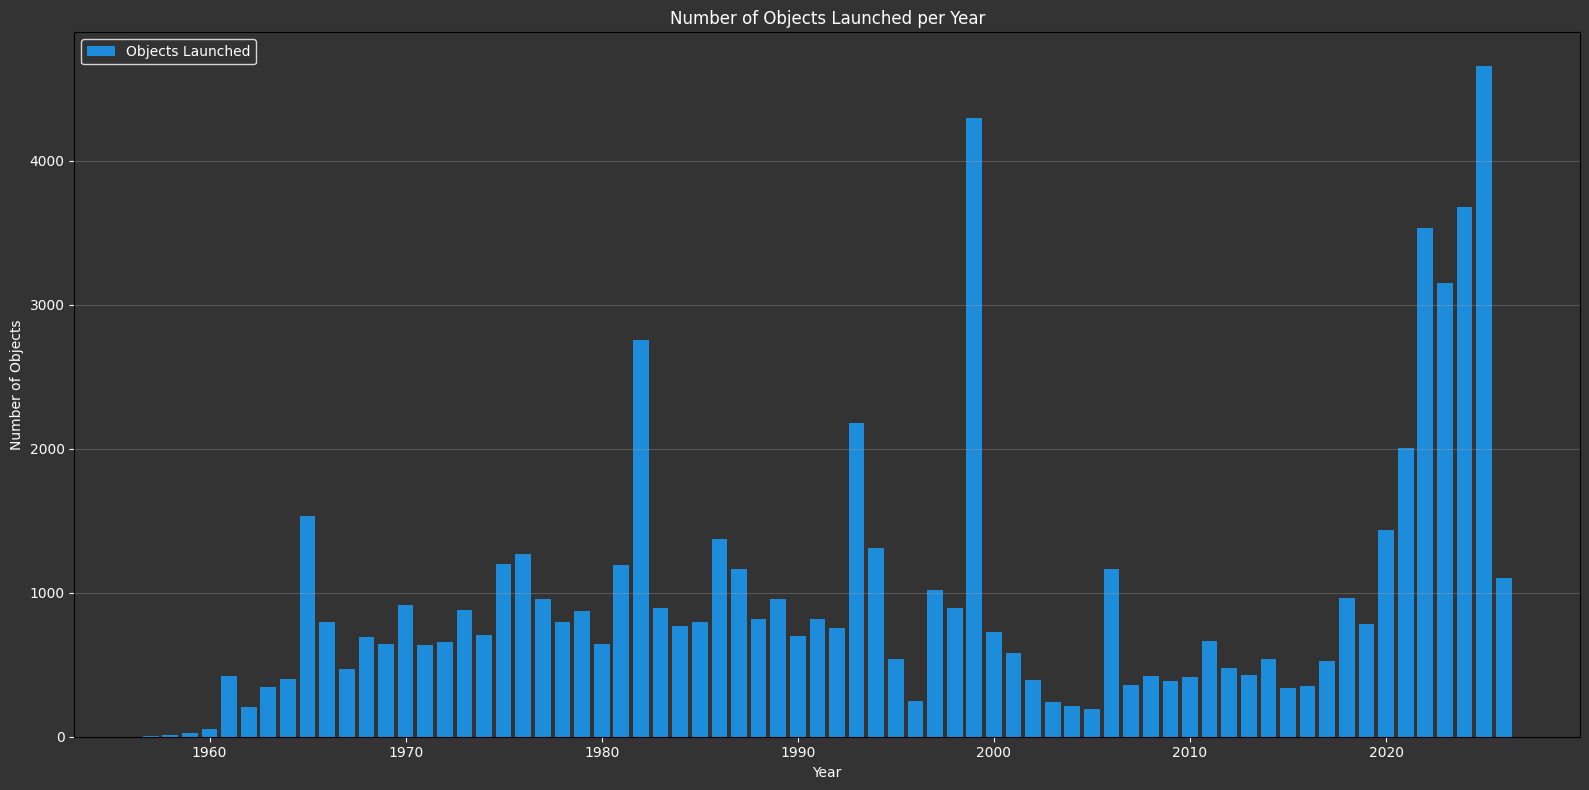

In [3]:
# Count the number of launches per year
if 'launch_date' in df_launches_per_year.columns:
  df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year
  launch_counts = df_launches_per_year['launch_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))
  
  plt.bar(launch_counts.index, launch_counts.values, color="#1d8cdb", label='Objects Launched')

  plt.title('Number of Objects Launched per Year')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend( loc='upper left')
  
  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/launches_per_year_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/launches_per_year_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
else:
  print('launch_date column not found in launches data.')

### Debris Growth Over Time: Annual Debris Object Counts

Show how the number of debris objects added to orbit changes over time.

**Method:**
- Pull launch years for objects labeled as debris.
- Ignore decay timing for this question because the goal is to measure debris added to orbit each year.
- Count the number of debris objects per year.

**Visuals:**
- A bar chart showing the number of debris objects added to orbit each year.

In [4]:
# Query: Debris objects per year
debris_query = """
SELECT
    satellites.norad_id,
    COALESCE(launch_events.launch_year, 0) AS debris_year
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'DEBRIS'
    AND launch_events.launch_year IS NOT NULL
ORDER BY launch_events.launch_year ASC;
"""

df_debris_per_year = pd.read_sql_query(debris_query, orbital_debris_conn)
df_debris_per_year['debris_year'] = pd.to_numeric(df_debris_per_year['debris_year'], errors='coerce')

df_debris_per_year.to_parquet('../data/clean/results/debris_per_year_exp.parquet', index=False)

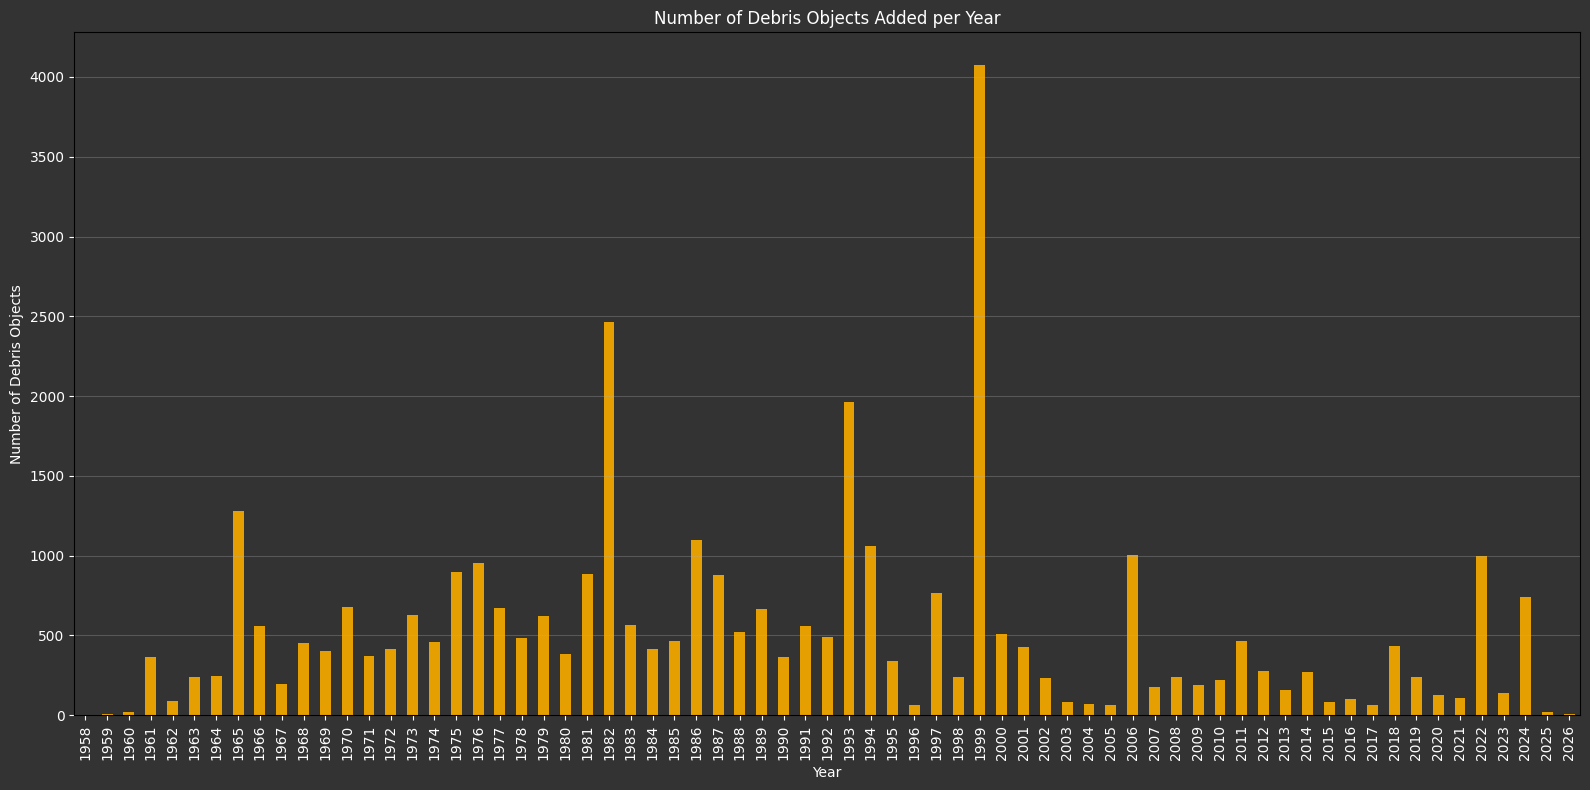

In [5]:
# Count debris objects per year
if 'debris_year' in df_debris_per_year.columns:
  debris_counts = df_debris_per_year['debris_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))

  debris_counts.plot(kind='bar', color='#E69F00')

  plt.title('Number of Debris Objects Added per Year')
  plt.xlabel('Year')
  plt.ylabel('Number of Debris Objects')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/debris_per_year_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/debris_per_year_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
else:
  print('debris_year column not found in debris data.')

### Object Type Distribution: How the Mix of Payloads, Rocket Bodies, and Debris Changes Over Time

Show how the proportions of payloads, rocket bodies, and debris have shifted over time, highlighting changes in the orbital environment.

**Method:**
- Query the satellites table (joined with launch_events) for object type and launch year.
- Group and count by year and object type.

**Visuals:**
- A stacked area chart showing the distribution of object types over time.
- A vertical bar chart alternative showing the same data for comparison.

In [6]:
# Query: Object type distribution by year
object_type_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_type_year = pd.read_sql_query(object_type_query, orbital_debris_conn)

# Convert to datetime and extract year
df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_type_year.to_parquet('../data/clean/results/object_type_year_exp.parquet', index=False)


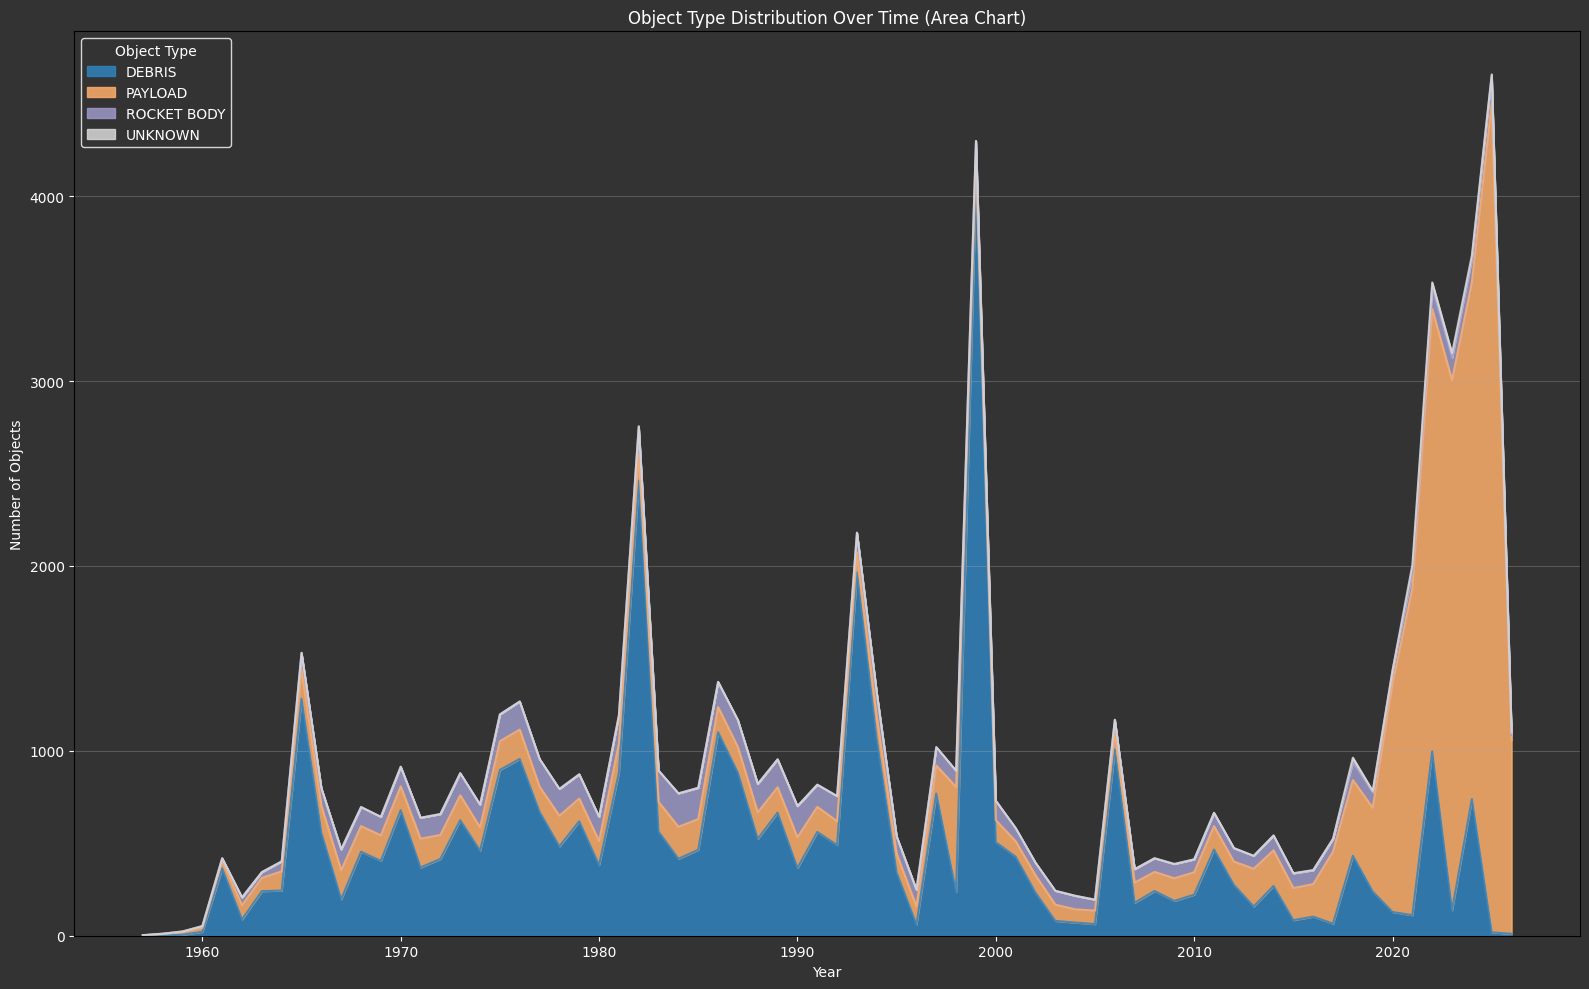

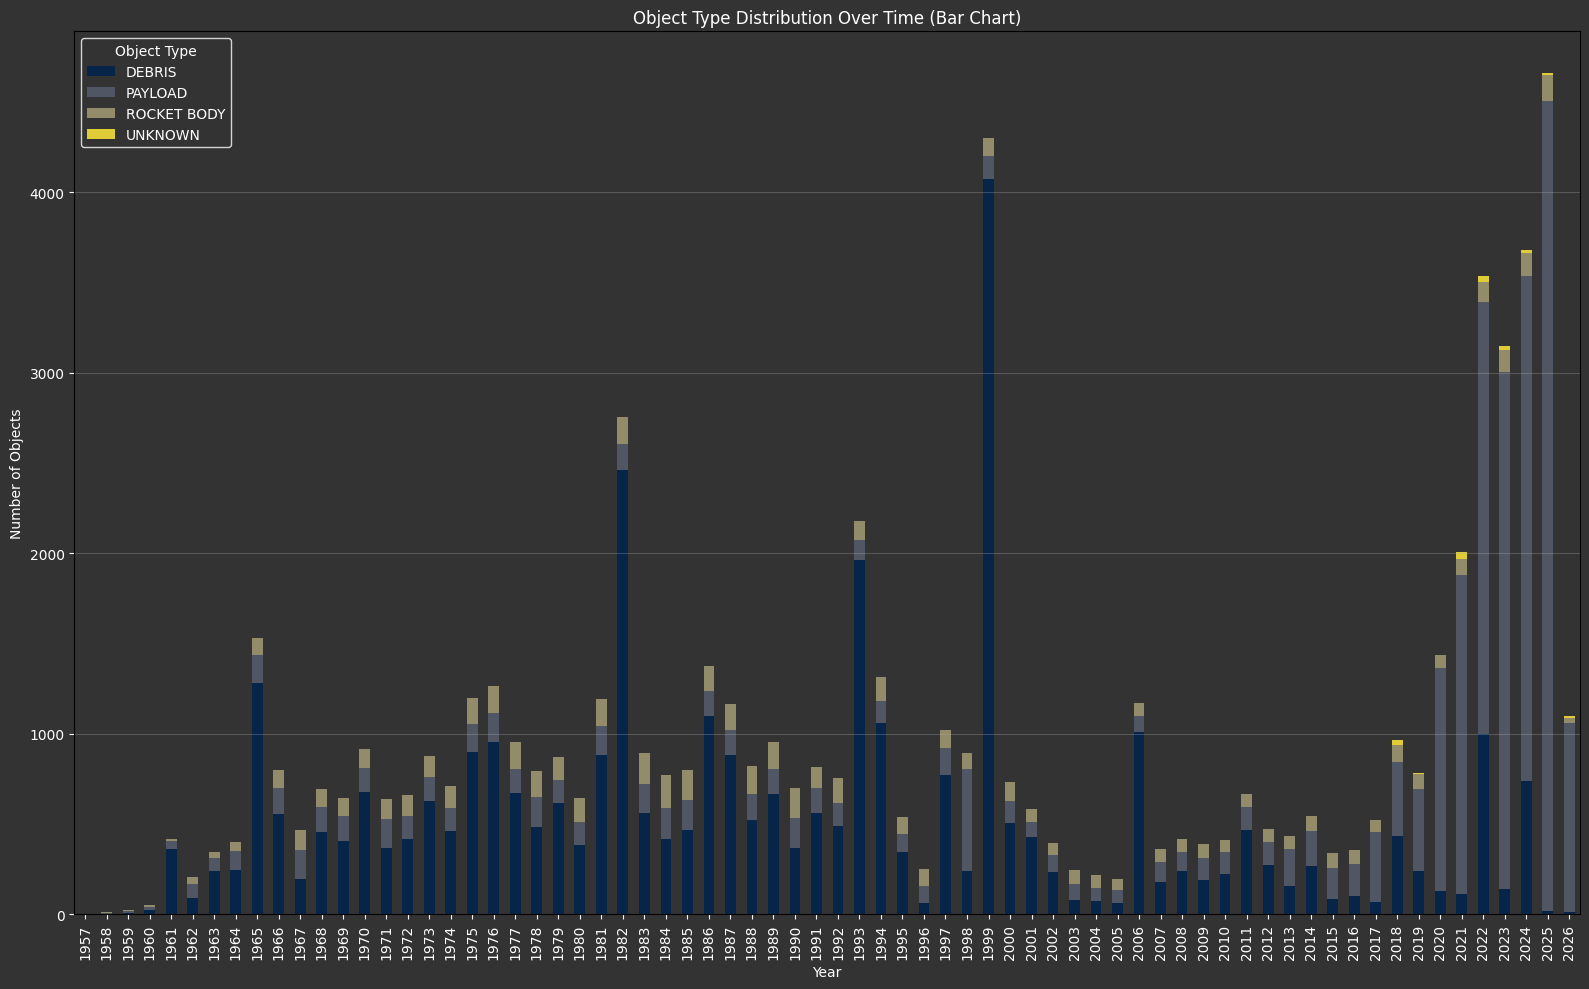

In [7]:
if 'launch_date' in df_type_year.columns and 'object_type' in df_type_year.columns:
  df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

  # Group by year and object type, count
  type_counts = df_type_year.groupby(['launch_year', 'object_type']).size().unstack(fill_value=0)

  # Stacked Area Chart
  plt.figure(figsize=(16,10))
  type_counts.plot.area(ax=plt.gca(), alpha=0.85, colormap='tab20c')

  plt.title('Object Type Distribution Over Time (Area Chart)')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/object_type_distribution_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

  # Vertical Bar Chart alternative
  plt.figure(figsize=(16,10))
  type_counts.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.85, colormap='cividis')

  plt.title('Object Type Distribution Over Time (Bar Chart)')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')
  
  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_bar_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/object_type_distribution_bar_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
else:
  print('launch_date or object_type columns not found in type_year table.')

### Linear vs Exponential Trend: In-Orbit Object Growth

Show when object growth in orbit changed from a slower steady rise to a much faster rise, and mark the year when that change happened.

**Method:**
- Leave out the current partial year so the fit is not biased.
- Compute a 3-year rolling average for easier viewing, but do not use it for the fit.
- Use a data-driven method to pick the best split year between the linear and exponential periods.
- Fit a linear trend before the split and an exponential trend after the split.


**Visuals:**
- Actual in-orbit object counts and 3-year average
- Launch missions per year
- Fitted linear and exponential trend lines
- A vertical line and note for the detected split year, plus fit details

In [8]:
# payload_share_pct is the payload share of each yearly in-orbit cohort.
# cumulative_in_orbit is the running total of yearly in-orbit counts ordered by launch_year.
linear_vs_exponential_trend_query = """
WITH yearly AS (
  SELECT
    launch_events.launch_year AS launch_year,
    COUNT(*) AS objects_in_orbit,
    COUNT(DISTINCT launch_events.launch_id) AS launch_missions,
    SUM(
      CASE
        WHEN UPPER(COALESCE(satellites.object_type, '')) = 'PAYLOAD' THEN 1
        ELSE 0
      END
    ) AS payload_in_orbit
  FROM satellites
  JOIN launch_events ON launch_events.launch_id = satellites.launch_id
  WHERE launch_events.launch_year IS NOT NULL
    AND COALESCE(satellites.in_orbit, 0) = 1
  GROUP BY launch_events.launch_year
)
SELECT
  yearly.launch_year,
  yearly.objects_in_orbit,
  yearly.launch_missions,
  yearly.payload_in_orbit,
  ROUND(100.0 * yearly.payload_in_orbit / NULLIF(yearly.objects_in_orbit, 0), 2) AS payload_share_pct,
  SUM(yearly.objects_in_orbit) OVER (ORDER BY yearly.launch_year) AS cumulative_in_orbit
FROM yearly
ORDER BY yearly.launch_year;
"""

df_sat = pd.read_sql_query(linear_vs_exponential_trend_query, orbital_debris_conn)

# Ensure launch_year is numeric for filtering and plotting.
df_sat['launch_year'] = pd.to_numeric(df_sat['launch_year'], errors='coerce')

# Save the query result to a parquet file for future use.
df_sat.to_parquet('../data/clean/results/linear_vs_exponential_trend_exp.parquet', index=False)

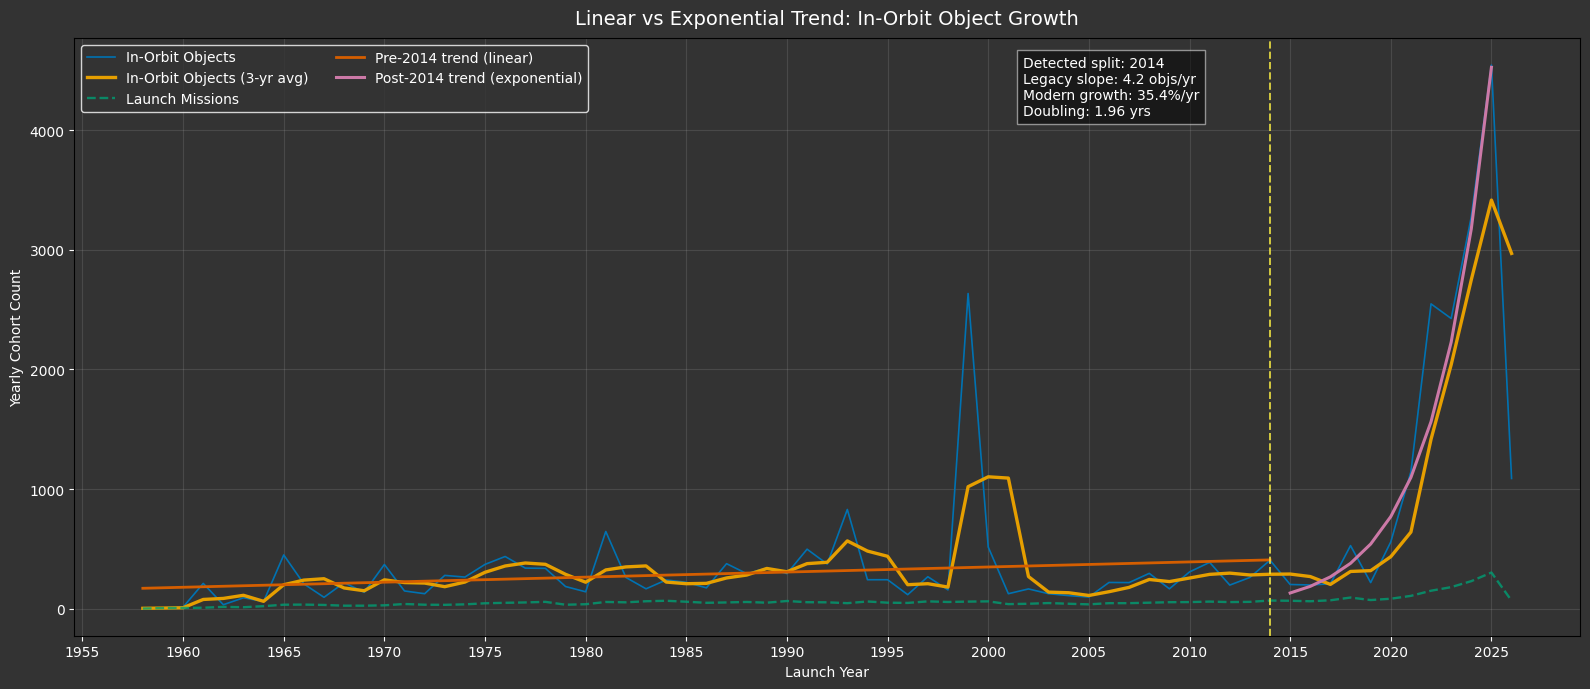

In [9]:
# Exclude the current partial year from fitting.
current_year = pd.Timestamp.now().year
df_sat_fit = df_sat[df_sat['launch_year'] < current_year].copy()

# Build a 3-year rolling average for smoother viewing only.
df_sat['objects_3yr_avg'] = df_sat['objects_in_orbit'].rolling(3, min_periods=1).mean()
df_sat_fit['objects_3yr_avg'] = df_sat_fit['objects_in_orbit'].rolling(3, min_periods=1).mean()

# Pick the split year from the data instead of hard-coding it.
split_year, _ = utils.choose_split_year(
    df_sat_fit,
    y_col='objects_in_orbit'
 )

# Fit the pre-split and post-split growth patterns.
pre, post, m_pre, b_exp, doubling_time_years = utils.fit_growth_regimes(
    df_sat_fit,
    split_year=split_year,
    y_col='objects_in_orbit'
 )

# Okabe-Ito palette (colorblind-safe) mapped to each series.
colors = {
    'objects_in_orbit': '#0072B2',
    'objects_3yr_avg': '#E69F00',
    'launch_missions': '#009E73',
    'trend_linear': '#D55E00',
    'trend_exponential': '#CC79A7',
    'split_line': '#F0E442'
}

# Create the figure and axis together for the layered plot below.
fig, ax1 = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='objects_in_orbit',
    linewidth=1.2,
    color=colors['objects_in_orbit'],
    ax=ax1,
    label='In-Orbit Objects'
 )

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='objects_3yr_avg',
    linewidth=2.4,
    color=colors['objects_3yr_avg'],
    ax=ax1,
    label='In-Orbit Objects (3-yr avg)'
 )

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='launch_missions',
    linewidth=1.7,
    linestyle='--',
    alpha=0.8,
    color=colors['launch_missions'],
    ax=ax1,
    label='Launch Missions'
 )

sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    color=colors['trend_linear'],
    ax=ax1,
    linewidth=2.0,
    label=f'Pre-{split_year} trend (linear)'
 )

sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    color=colors['trend_exponential'],
    ax=ax1,
    linewidth=2.2,
    label=f'Post-{split_year} trend (exponential)'
 )

ax1.axvline(split_year, color=colors['split_line'], linestyle='--', alpha=0.85, linewidth=1.4)

ax1.text(
    0.63, 0.97,
    f'Detected split: {split_year}\n'
    f'Legacy slope: {m_pre:,.1f} objs/yr\n'
    f'Modern growth: {b_exp:.1%}/yr\n'
    f'Doubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
 )

ax1.set_title('Linear vs Exponential Trend: In-Orbit Object Growth', fontsize=14, pad=10)
ax1.set_xlabel('Launch Year')
ax1.set_ylabel('Yearly Cohort Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/linear_vs_exponential_trend_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/linear_vs_exponential_trend_exp.png', bbox_inches='tight', dpi=300)
plt.show()

## High-Risk Object Distribution

Measure how high-risk objects are spread across orbit, focusing on objects above the risk thresholds. The goal is to show how common they are, where they sit, and how large they are.

**Explore:**
- Mass Distribution: Mass of high-risk objects, when mass is available
- High-Risk Object Counts: Number and share of objects above the risk thresholds
- Orbit Class Breakdown: High-risk objects by orbit class
- Altitude Band Analysis: High-risk objects in the 400–600 km LEO band

In [10]:
# Pull in-orbit objects with the fields needed for high-risk analysis.
# altitude_km is the midpoint of apogee and perigee, used for LEO band analysis.
high_risk_query = '''
SELECT
  satellites.norad_id,
  COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
  orbital_data.proxy_mass_kg,
  (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 AS altitude_km,
  risk_assessment.velocity_kms,
  risk_assessment.kinetic_joules
FROM satellites
JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE satellites.in_orbit = 1
  AND risk_assessment.kinetic_joules IS NOT NULL;
'''

df_all_sats = pd.read_sql_query(high_risk_query, orbital_debris_conn)
df_all_sats['risk_category'] = df_all_sats.apply(utils.classify_risk_category, axis=1)

df_high_risk = df_all_sats[
  df_all_sats['risk_category'] == 'Extremely High Risk'
].copy()

# Save the query result to a parquet file for future use.
df_high_risk.to_parquet('../data/clean/results/high_risk_sats_exp.parquet', index=False)

### High-Risk Object Counts

Quantify the number and proportion of high-risk objects in orbit, defined by exceeding velocity and/or kinetic energy thresholds.

**Method:**
- Count the total number of objects and the subset classified as high-risk based on velocity/kinetic energy criteria.
- Calculate the share of high-risk objects relative to the total population.

**Output:**
- Report the total count of objects with risk data, the count of high-risk objects, and the percentage they represent.

In [11]:
# Count and share
risk_data_objects = len(df_all_sats)
high_risk_count = len(df_high_risk)
high_risk_share = high_risk_count / risk_data_objects if risk_data_objects else float('nan')

print(f'Total objects with risk data: {risk_data_objects}')
print(f'High-risk objects: {high_risk_count} of {risk_data_objects} ({high_risk_share:.2%})')

# Validation
print('Nulls per column:')
display(df_high_risk.isnull().sum())


Total objects with risk data: 33406
High-risk objects: 12800 of 33406 (38.32%)
Nulls per column:


norad_id          0
orbit_class       0
proxy_mass_kg     0
altitude_km       0
velocity_kms      0
kinetic_joules    0
risk_category     0
dtype: int64

### Mass Distribution: High-Risk Objects

Show the mass distribution of extremely high-risk objects in orbit, highlighting outliers and differences by orbit class.

**Method:**
- Use available mass and orbit class data.
- Filter for "Extremely High Risk" objects (by velocity/kinetic energy).

**Visuals:**
- A histogram of all high-risk masses, colored by orbit_class.
- A strip plot to show mass distribution by orbit_class.

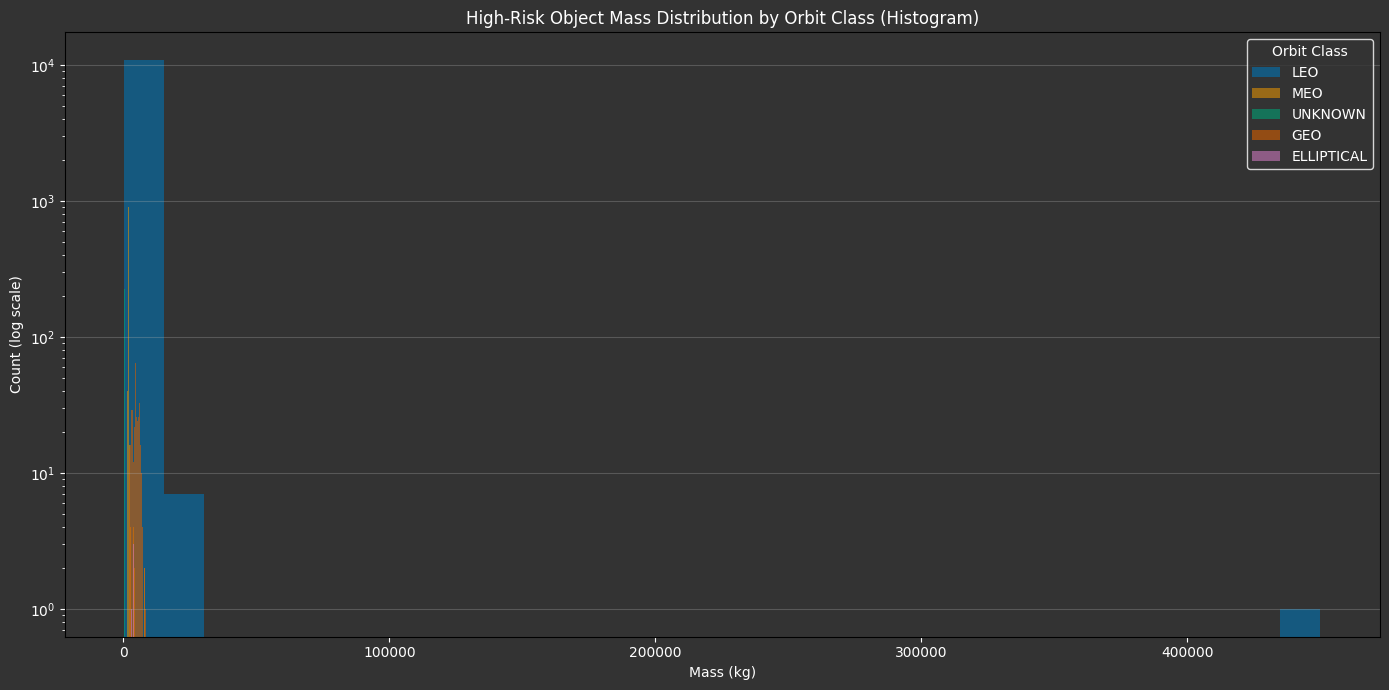

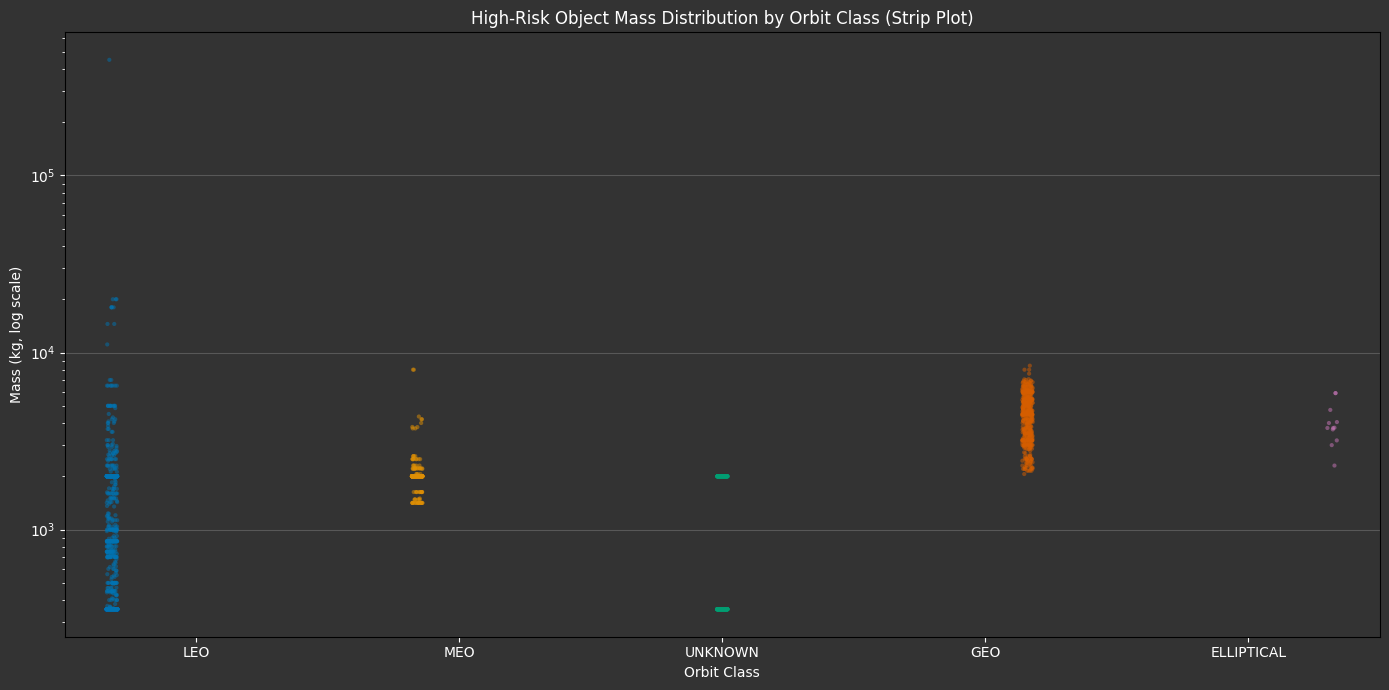

Objects with nonzero mass and orbit class: 12800


In [12]:
# Mass distribution for high-risk objects: histogram and strip plot by orbit_class
if 'proxy_mass_kg' in df_high_risk.columns and 'orbit_class' in df_high_risk.columns:
    mass_nonzero = df_high_risk[['proxy_mass_kg', 'orbit_class']].dropna()
    mass_nonzero = mass_nonzero[mass_nonzero['proxy_mass_kg'] > 0]
    
    # Histogram (all high-risk masses, colored by orbit_class)
    plt.figure(figsize=(14, 7))
    
    for orbit_class in mass_nonzero['orbit_class'].unique():
        subset = mass_nonzero[mass_nonzero['orbit_class'] == orbit_class]
        plt.hist(subset['proxy_mass_kg'], bins=30, alpha=0.6, label=orbit_class)
        
    plt.yscale('log')
    plt.xlabel('Mass (kg)')
    plt.ylabel('Count (log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Histogram)')
    plt.legend(title='Orbit Class')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_hist_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_hist_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Strip plot (each point = object, grouped by orbit_class)
    plt.figure(figsize=(14, 7))
    
    sns.stripplot(x='orbit_class', y='proxy_mass_kg', data=mass_nonzero, hue='orbit_class', palette='colorblind', size=3, dodge=True, alpha=0.5)
    
    plt.yscale('log')
    plt.xlabel('Orbit Class')
    plt.ylabel('Mass (kg, log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Strip Plot)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_strip_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_strip_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects with nonzero mass and orbit class: {len(mass_nonzero)}')
else:
    print('proxy_mass_kg or orbit_class column not found in high-risk data.')

### Orbit Class Breakdown: High-Risk Objects by Orbit Class

Show how high-risk objects are distributed across orbit classes (LEO, MEO, GEO, etc.).

**Method:**
- Use the high-risk subset from above.
- Group and count by orbit class.

**Visuals:**
- A bar chart showing the distribution of high-risk objects across orbit classes.
- A pie chart alternative showing orbit class percentages for comparison.

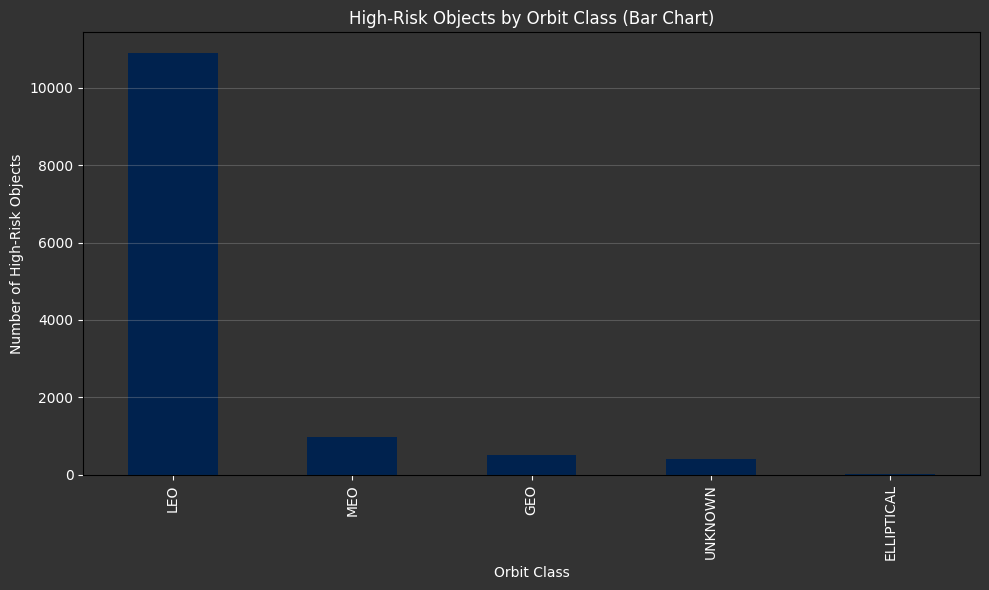

In [13]:
# Group high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    orbit_counts.plot(kind='bar', colormap='cividis')
    
    plt.title('High-Risk Objects by Orbit Class (Bar Chart)')
    plt.xlabel('Orbit Class')
    plt.ylabel('Number of High-Risk Objects')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/hr_orbit_class_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/hr_orbit_class_exp.png', bbox_inches='tight', dpi=300)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

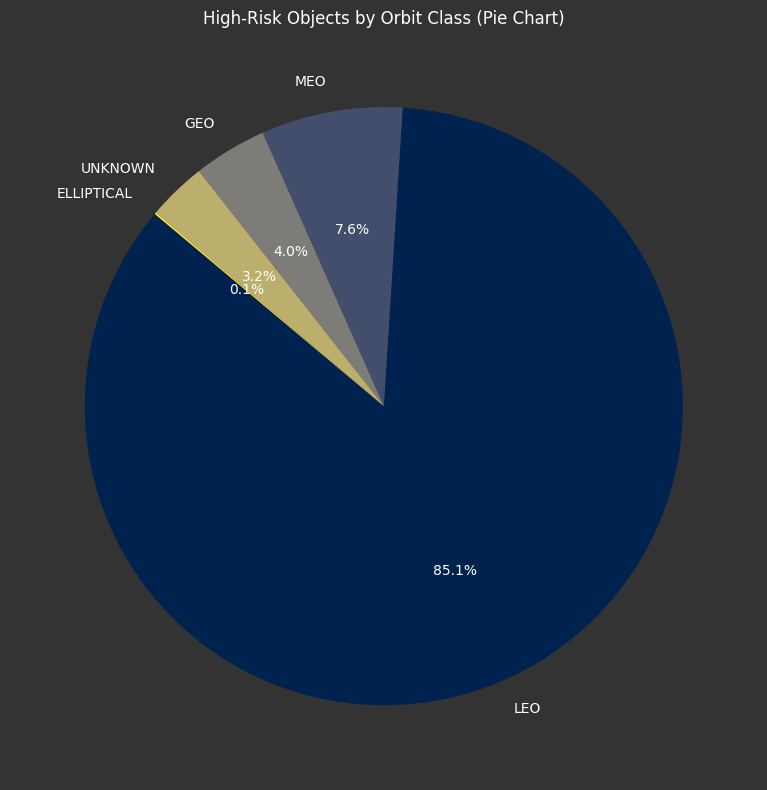

In [14]:
# pie chart of high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts()
    
    plt.figure(figsize=(8,8))
    orbit_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='cividis')
    
    plt.title('High-Risk Objects by Orbit Class (Pie Chart)')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/hr_orbit_class_pie_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/hr_orbit_class_pie_exp.png', bbox_inches='tight', dpi=300)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

### Altitude Band Analysis: 400–600 km LEO High-Risk Objects

Focus on high-risk objects in the 400–600 km altitude band (LEO), a region of particular congestion and risk.

**Method:**
- Filter high-risk objects for those with altitude between 400 and 600 km.

**Visuals:**
- A histogram of their altitudes to show distribution concentration across that entire altitude band.

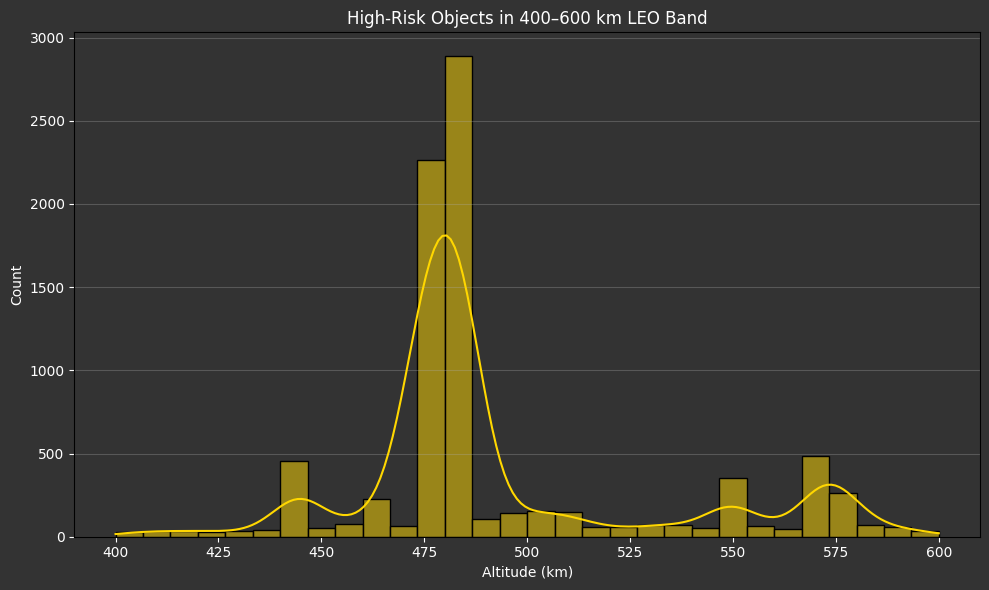

Objects in 400 - 600 km band: 8469


In [15]:
# Filter for 400–600 km LEO high-risk objects
if 'altitude_km' in df_high_risk.columns:
    leo_band = df_high_risk[(df_high_risk['altitude_km'] >= 400) & (df_high_risk['altitude_km'] <= 600)]
    
    plt.figure(figsize=(10,6))
    sns.histplot(leo_band['altitude_km'], bins=30, kde=True, color='gold')
    
    plt.title('High-Risk Objects in 400–600 km LEO Band')
    plt.xlabel('Altitude (km)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_banded_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_banded_exp.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects in 400 - 600 km band: {len(leo_band)}')
else:
    print('altitude column not found in high-risk data.')

### Zombie Payload Concentrations

Measure how many in-orbit payload satellites are no longer operational ("zombie" payloads), identify who operates them, and show how concentrated ownership is across operator groups.

**Explore:**
- Operational Status: Share of operational vs. non-operational in-orbit payloads
- Zombie Payloads by Owner/Operator: Which owner/operator groups have the most non-operational ("zombie") payloads
- Ownership/Operator Diversity: Number of unique owner/operator pairs and their in-orbit payload counts

### Operational Status: Share of operational vs. non-operational payloads

Estimate the current in-orbit payload status mix, focusing on operational vs. non-operational payloads.

**Method:**
- Query all in-orbit payloads and keep status values, assigning missing values to "UNKNOWN".
- Count payloads by status.
- Calculate share for each status and report key operational vs. non-operational percentages.

**Output:**
- Report the total payload count, the count of operational, and the count of non-operational payloads.
- Display full count and percentage results for each status in table format.

**Visuals:**
- A bar chart showing the count of payloads by status (Operational, Non-Operational, UNKNOWN).

**Data limits:**
- Status values depend on source data quality and update frequency.
- "UNKNOWN" can include truly unknown and missing statuses.

Total in-orbit payloads in this status view: 18392
Operational: 14855 (80.77%)
Non-operational: 1465 (7.97%)


,status_count,status_share
ops_status,,
OPERATIONAL,14855,0.807688
NON-OPERATIONAL,1465,0.079654
PARTIAL,479,0.026044
EXTENDED MISSION,16,0.000870
BACKUP/STANDBY,23,0.001251
STANDBY,6,0.000326
DECAYED,0,0.000000
UNKNOWN,1548,0.084167


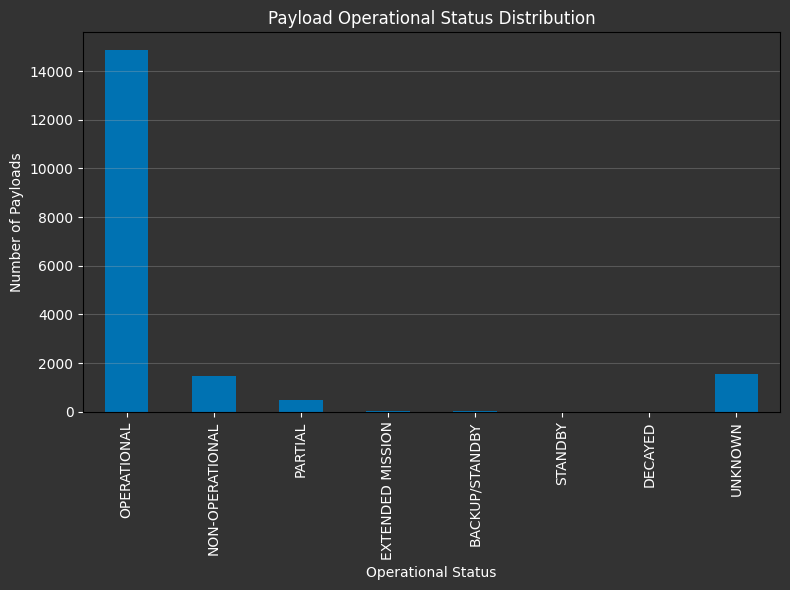

In [16]:
ops_status_query = """
SELECT
    satellites.norad_id,
    launch_events.launch_date,
    satellites.object_type,
    COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status
FROM satellites
LEFT JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1
ORDER BY launch_events.launch_date ASC;
"""

df_ops_status = pd.read_sql_query(ops_status_query, orbital_debris_conn)
df_ops_status.to_parquet('../data/clean/results/ops_status_query_exp.parquet', index=False)

status_order = [
    'OPERATIONAL',
    'NON-OPERATIONAL',
    'PARTIAL',
    'EXTENDED MISSION',
    'BACKUP/STANDBY',
    'STANDBY',
    'DECAYED',
    'UNKNOWN'
 ]

if df_ops_status.empty:
    print('No in-orbit payload status data returned. Skipping status chart.')
else:
    status_counts = df_ops_status['ops_status'].value_counts().reindex(status_order, fill_value=0)
    total_payloads = int(status_counts.sum())
    status_share = (status_counts / total_payloads).fillna(0)

    op_count = int(status_counts.get('OPERATIONAL', 0))
    non_op_count = int(status_counts.get('NON-OPERATIONAL', 0))
    op_share = op_count / total_payloads if total_payloads else 0
    non_op_share = non_op_count / total_payloads if total_payloads else 0

    print(f'Total in-orbit payloads in this status view: {total_payloads}')
    print(f'Operational: {op_count} ({op_share:.2%})')
    print(f'Non-operational: {non_op_count} ({non_op_share:.2%})')

    display(
        pd.DataFrame({
            'status_count': status_counts,
            'status_share': status_share
        })
    )

    plt.figure(figsize=(8,6))
    status_counts.plot(kind='bar', color='#0072B2')
    plt.title('Payload Operational Status Distribution')
    plt.xlabel('Operational Status')
    plt.ylabel('Number of Payloads')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/ops_status_distribution_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/ops_status_distribution_exp.png', bbox_inches='tight', dpi=300)
    plt.show()


### Zombie Payloads by Owner/Operator: Top Zombie Contributors

Show which owner or operator groups have the most non-operational in-orbit payloads.

**Method:**
- Build the in-orbit payload set with owner and operator fields.
- Filter to non-operational payloads.
- Group by owner and operator, then count zombie payloads.
- Show the top groups and roll the rest into `OTHER` so the chart stays readable.

### Ownership/Operator Diversity: Number of unique owners/operators and their object counts

Add context for how concentrated in-orbit payload ownership is.

**Method:**
- Count unique owner and operator pairs in the in-orbit payload set.
- Show payload counts by owner and operator from highest to lowest.

**Status buckets used in this section:**
- **Operational Payloads:** `ops_status = OPERATIONAL`
- **Non-Operational Payloads (Zombie):** `ops_status = NON-OPERATIONAL`
- **Misc Status Payloads:** `ops_status` in `PARTIAL`, `EXTENDED MISSION`, `BACKUP/STANDBY`, `STANDBY`
- **Unknown Status Payloads:** `ops_status = UNKNOWN` and missing values mapped to `UNKNOWN`

**Data limits:**
- Missing owner or operator mappings are grouped as `UNKNOWN`, which can affect concentration estimates.

In [17]:
base_contrib_query = """
SELECT
  satellites.norad_id,
  COALESCE(ownership_operators.owner, 'UNKNOWN') AS owner,
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_operator,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status
FROM satellites
LEFT JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1;
"""

df_contrib = pd.read_sql_query(base_contrib_query, orbital_debris_conn)
df_contrib.to_parquet('../data/clean/results/base_contrib_exp.parquet', index=False)

df_zombie_contributors = df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL'].copy()
all_objects = utils.query_all_satellites(orbital_debris_conn)

# Safe defaults let downstream cells run even if this query comes back empty.
owner_counts = pd.DataFrame(columns=['owner', 'country_operator', 'object_count'])
operational_counts = pd.DataFrame(columns=['owner', 'country_operator', 'operational_count'])
zombie_counts = pd.DataFrame(columns=['owner', 'country_operator', 'zombie_count'])
misc_counts = pd.DataFrame(columns=['owner', 'country_operator', 'misc_count'])
unknown_counts = pd.DataFrame(columns=['owner', 'country_operator', 'unknown_count'])
zombie_owner_counts = pd.DataFrame(columns=['owner', 'country_operator', 'zombie_payload_count'])
top_owners = pd.DataFrame(columns=['owner', 'country_operator', 'object_count', 'operational_count', 'zombie_count', 'misc_count', 'unknown_count', 'first_year', 'last_year', 'payload_pct'])

if not df_contrib.empty and not all_objects.empty and not df_launches_per_year.empty:
  first_launch_year = pd.to_datetime(all_objects['launch_date'], errors='coerce').dt.year.min()
  last_launch_year = pd.to_datetime(all_objects['launch_date'], errors='coerce').dt.year.max()

  # Build each status count separately, then merge them into one summary table.
  owner_counts = (
    df_contrib
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='object_count')
    .sort_values('object_count', ascending=False)
    .copy()
  )

  operational_counts = (
    df_contrib[df_contrib['ops_status'] == 'OPERATIONAL']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='operational_count')
  )

  zombie_counts = (
    df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='zombie_count')
  )

  misc_counts = (
    df_contrib[df_contrib['ops_status'].isin(['PARTIAL', 'EXTENDED MISSION', 'BACKUP/STANDBY', 'STANDBY'])]
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='misc_count')
  )

  unknown_counts = (
    df_contrib[df_contrib['ops_status'] == 'UNKNOWN']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='unknown_count')
  )
  
  zombie_owner_counts = (
      df_zombie_contributors
      .groupby(['owner', 'country_operator'])
      .size()
      .reset_index(name='zombie_payload_count')
      .sort_values('zombie_payload_count', ascending=False)
      .copy()
  )
  
  # Add first and last launch year for each owner/operator pair.
  activity_span = (
    df_contrib
    .merge(df_launches_per_year[['norad_id', 'launch_year']], on='norad_id', how='left')
    .groupby(['owner', 'country_operator'])
    .agg(first_year=('launch_year', 'min'), last_year=('launch_year', 'max'))
    .reset_index()
  )
  
  # Start with the top owner/operator groups, then merge in status counts and year span.
  top_owners = owner_counts.head(MAX_TOP).copy()
  top_owners = top_owners.merge(operational_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(zombie_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(misc_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(unknown_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(activity_span, on=['owner', 'country_operator'], how='left')
  top_owners[['operational_count', 'zombie_count', 'misc_count', 'unknown_count']] = top_owners[['operational_count', 'zombie_count', 'misc_count', 'unknown_count']].fillna(0).astype(int)

  # Roll everyone outside the top group into one OTHER row.
  all_others_count = owner_counts['object_count'].sum() - top_owners['object_count'].sum()
  all_others_operational = operational_counts['operational_count'].sum() - top_owners['operational_count'].sum()
  all_others_zombie = zombie_counts['zombie_count'].sum() - top_owners['zombie_count'].sum()
  all_others_misc = misc_counts['misc_count'].sum() - top_owners['misc_count'].sum()
  all_others_unknown = unknown_counts['unknown_count'].sum() - top_owners['unknown_count'].sum()

  if all_others_count > 0:
    other_row = pd.DataFrame([{
      'owner': 'OTHER',
      'country_operator': f'{max(len(owner_counts) - MAX_TOP, 0)} FILTERED OWNER/OPERATORS',
      'object_count': all_others_count,
      'operational_count': all_others_operational,
      'zombie_count': all_others_zombie,
      'misc_count': all_others_misc,
      'unknown_count': all_others_unknown,
      'first_year': first_launch_year,
      'last_year': last_launch_year
    }])
    top_owners = pd.concat([top_owners, other_row], ignore_index=True)

  # Apply the same OTHER logic to the zombie-only table so both views stay aligned.
  top_zombie_owners = zombie_owner_counts.head(MAX_TOP).copy()
  zombie_other_count = zombie_owner_counts['zombie_payload_count'].sum() - top_zombie_owners['zombie_payload_count'].sum()
  zombie_other_groups = len(zombie_owner_counts) - len(top_zombie_owners)

  if zombie_other_count > 0:
    zombie_other_row = pd.DataFrame([{
      'owner': 'OTHER',
      'country_operator': f'{zombie_other_groups} FILTERED OWNER/OPERATORS',
      'zombie_payload_count': zombie_other_count
    }])
    zombie_owner_counts = pd.concat([top_zombie_owners, zombie_other_row], ignore_index=True)
  else:
    zombie_owner_counts = top_zombie_owners

  total_payload_count = owner_counts['object_count'].sum()
  top_owners['payload_pct'] = top_owners['object_count'] / total_payload_count
else:
  print('One or more required dataframes are empty. Skipping contributor prep.')


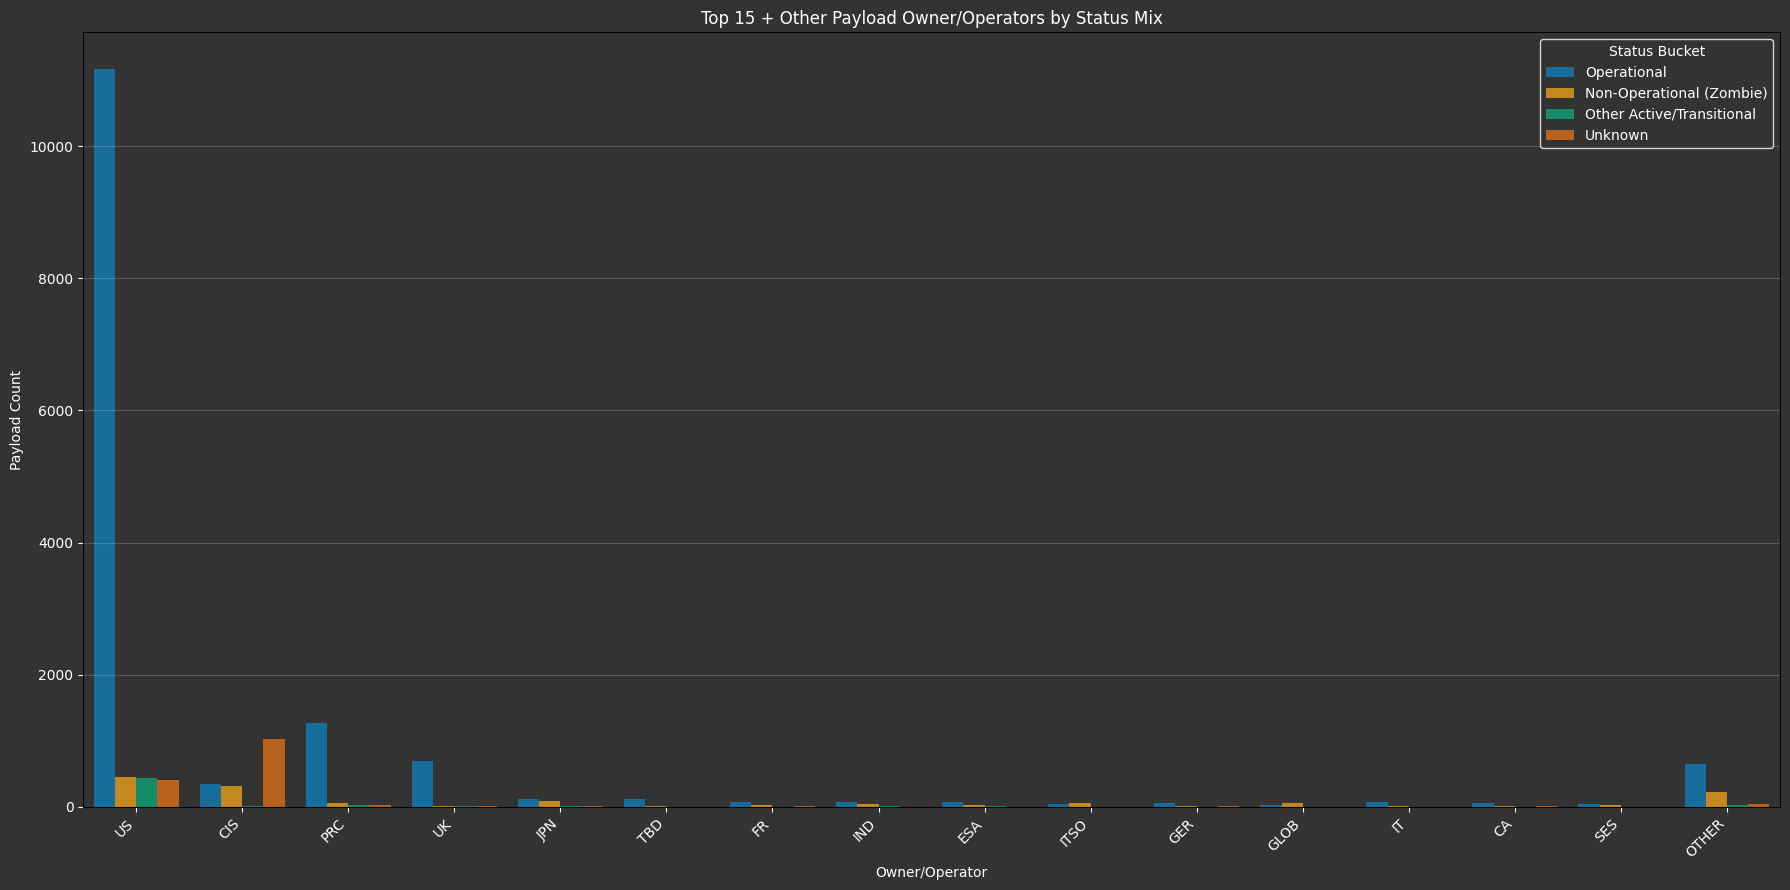

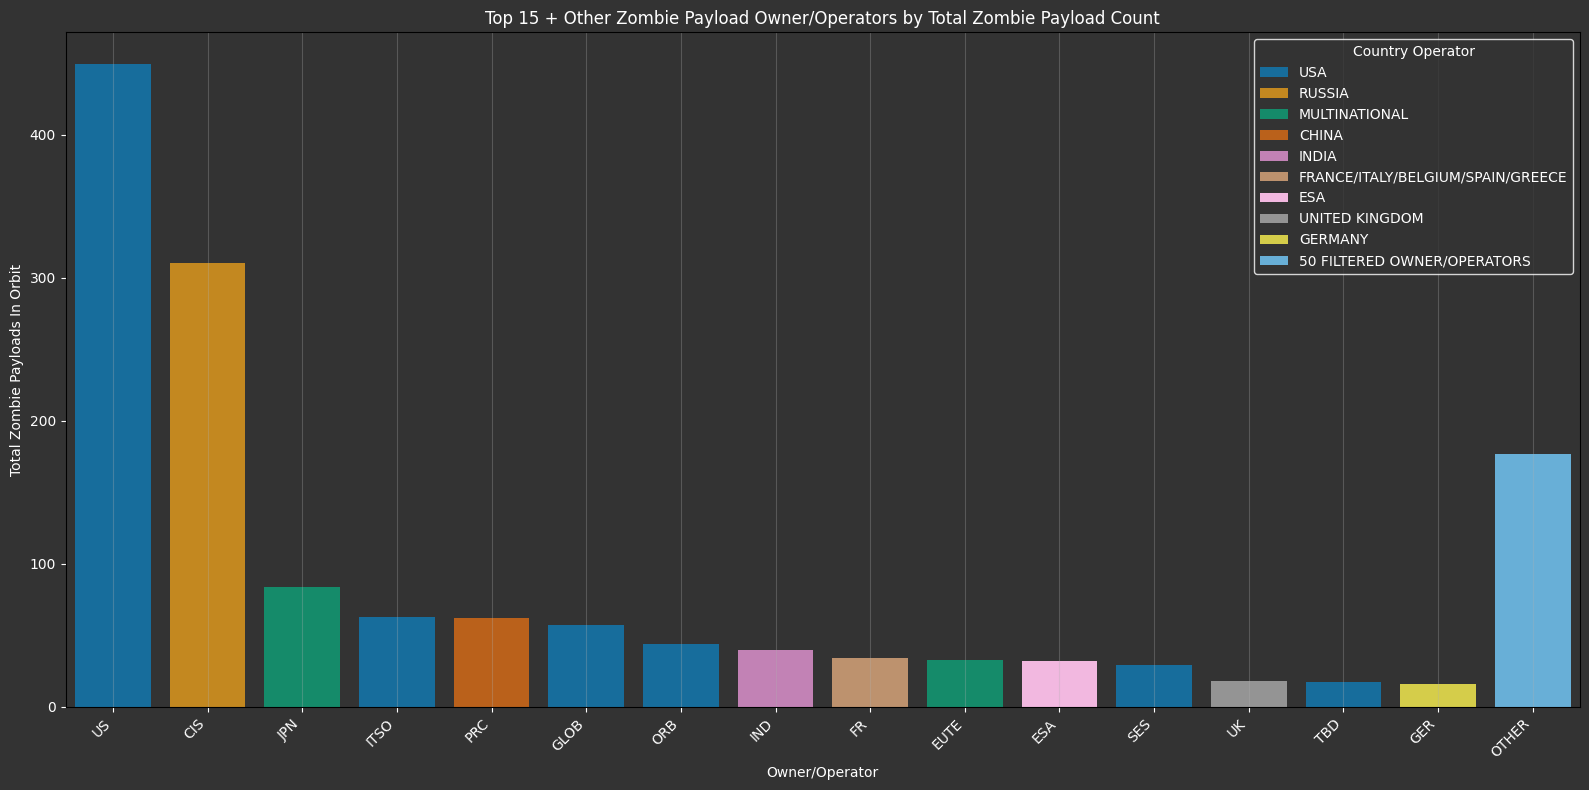

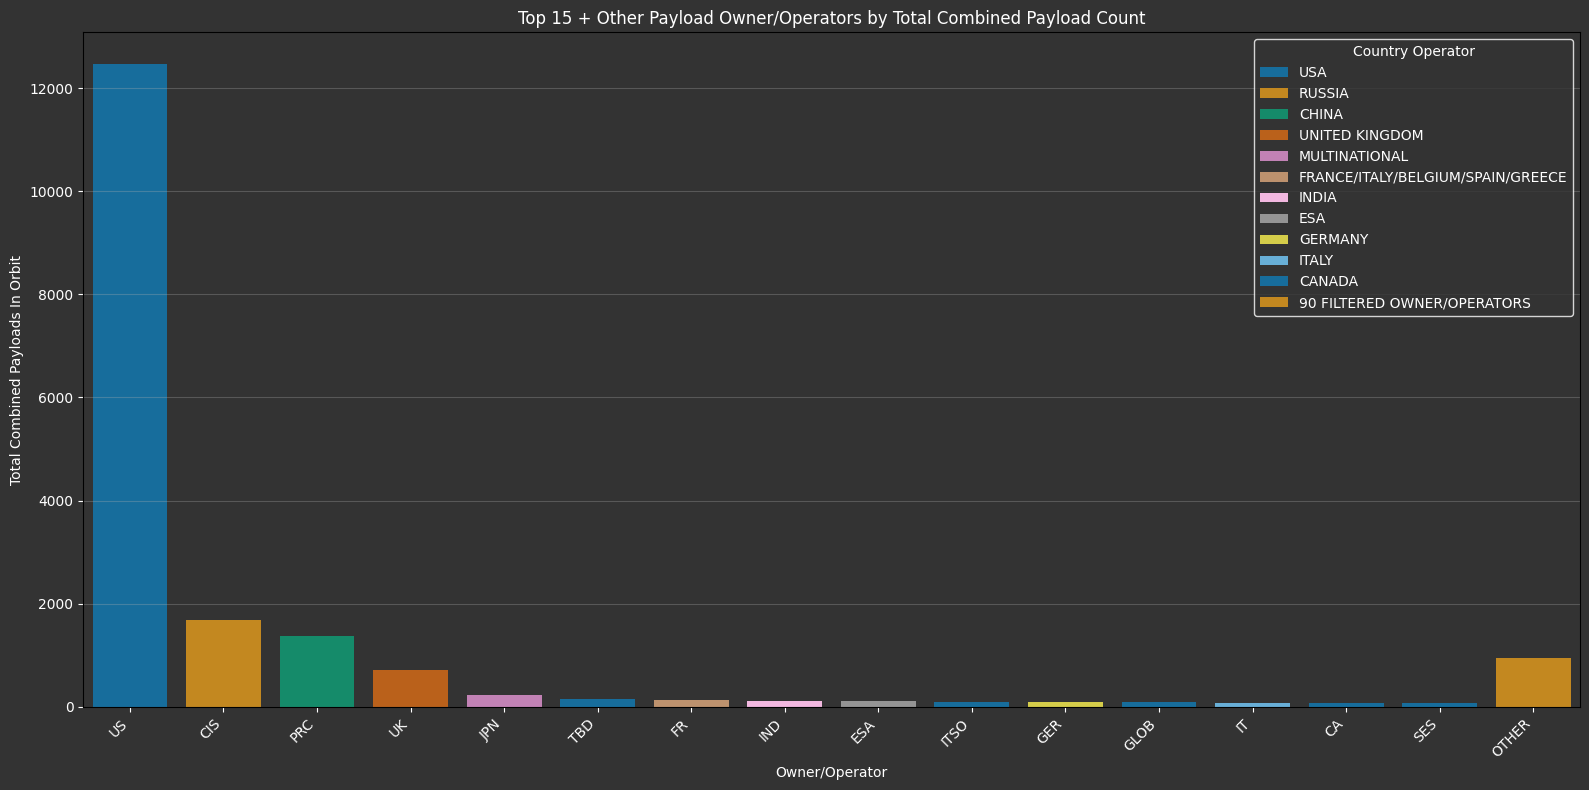

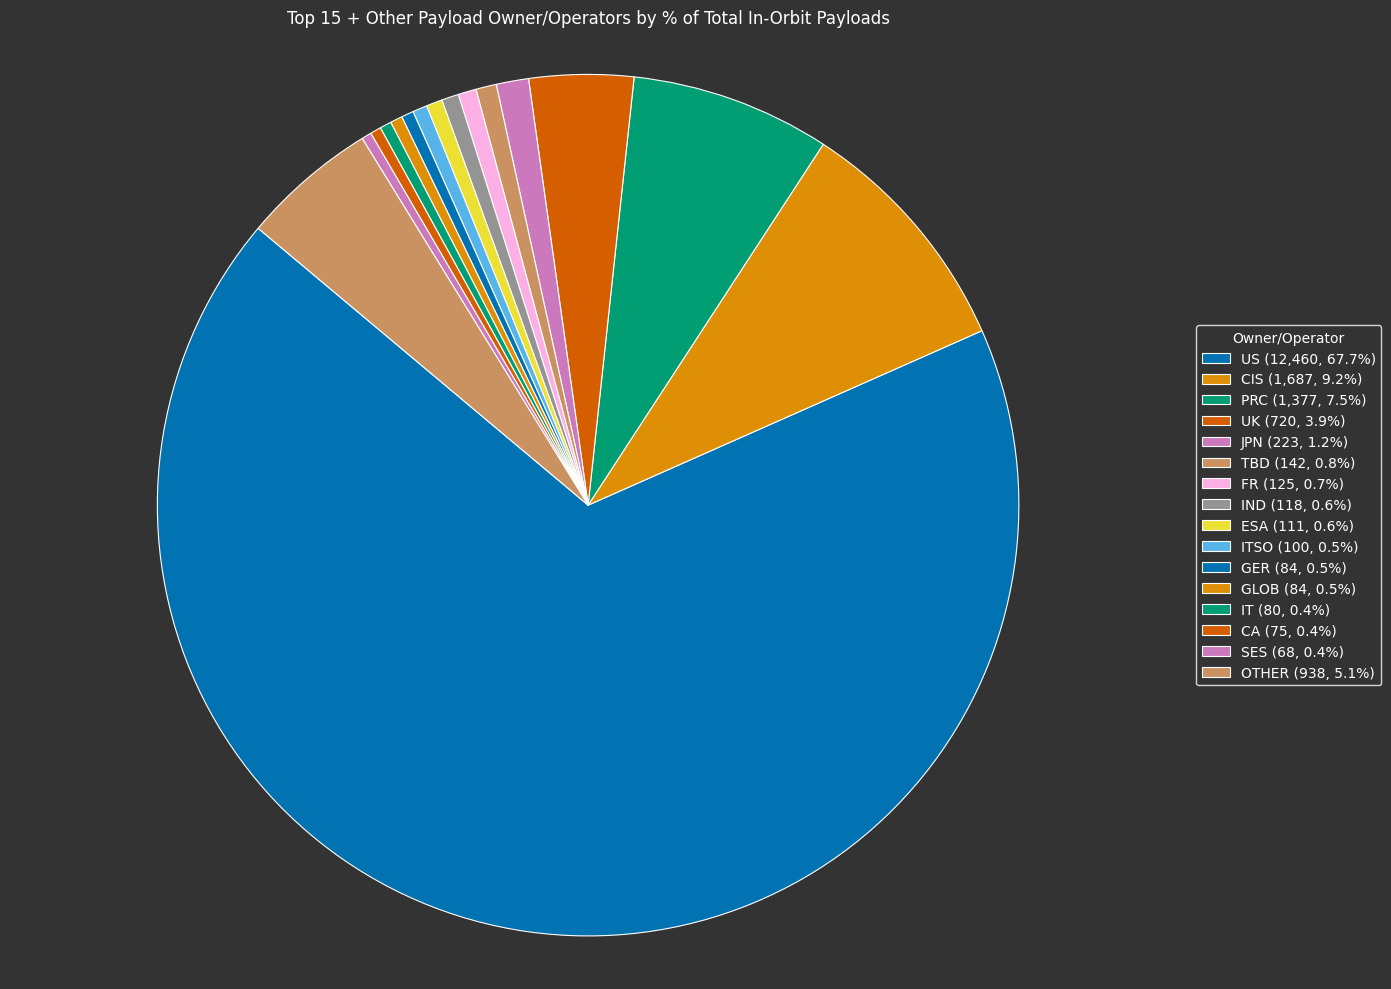

In [18]:
if top_owners.empty:
  print('No contributor data available for ownership charts.')
else:
  # Grouped status mix by owner/operator (operational, zombie, misc, unknown).
  plot_df = top_owners.copy()
  top_owner_label = f'Top {MAX_TOP} + Other' if (plot_df['owner'] == 'OTHER').any() else f'Top {MAX_TOP}'
  zombie_owner_label = (
      f'Top {MAX_TOP} + Other'
      if not zombie_owner_counts.empty and (zombie_owner_counts['owner'] == 'OTHER').any()
      else f'Top {MAX_TOP}'
  )

  status_cols = ['operational_count', 'zombie_count', 'misc_count', 'unknown_count']

  for col in status_cols:
    if col not in plot_df.columns:
      plot_df[col] = 0

  status_long = plot_df.melt(
      id_vars=['owner', 'country_operator'],
      value_vars=status_cols,
      var_name='status_bucket',
      value_name='count'
  )
  status_labels = {
      'operational_count': 'Operational',
      'zombie_count': 'Non-Operational (Zombie)',
      'misc_count': 'Other Active/Transitional',
      'unknown_count': 'Unknown'
  }
  status_long['status_bucket'] = status_long['status_bucket'].map(status_labels)

  plt.figure(figsize=(18, 9))
  sns.barplot(data=status_long, x='owner', y='count', hue='status_bucket')
  plt.title(f'{top_owner_label} Payload Owner/Operators by Status Mix')
  plt.xlabel('Owner/Operator')
  plt.ylabel('Payload Count')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Status Bucket', loc='upper right', frameon=True)
  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/owner_status_mix_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/owner_status_mix_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

  if not zombie_owner_counts.empty:
    # Bar chart of top contributing owners to zombie payloads
    plt.figure(figsize=(16, 8))
    sns.barplot(
        data=zombie_owner_counts,
        x='owner',
        y='zombie_payload_count',
        hue='country_operator',
        palette='colorblind'
    )

    plt.title(f'{zombie_owner_label} Zombie Payload Owner/Operators by Total Zombie Payload Count')
    plt.xlabel('Owner/Operator')
    plt.ylabel('Total Zombie Payloads In Orbit')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='x', alpha=0.3)
    plt.legend(title='Country Operator', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/zombie_top_contributors_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/zombie_top_contributors_exp.png', bbox_inches='tight', dpi=300)
    plt.show()
  else:
    print('No zombie contributor rows available for the zombie chart.')

  # Bar chart of top owners by total payload count
  plt.figure(figsize=(16, 8))
  sns.barplot(data=top_owners, x='owner', y='object_count', hue='country_operator', palette='colorblind')

  plt.title(f'{top_owner_label} Payload Owner/Operators by Total Combined Payload Count')
  plt.xlabel('Owner/Operator')
  plt.ylabel('Total Combined Payloads In Orbit')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Country Operator', loc='upper right', frameon=True)

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/contribution_report_top_owners_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/contribution_report_top_owners_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

  # Pie chart with side legend (stats moved to legend labels)
  plt.figure(figsize=(14, 10))

  # Create a copy of the top_owners dataframe so we don't modify the original.
  top_owners_pie = top_owners.copy()

  # Calculate percentages and create the legend labels with the owner name, count, and percentage.
  total_in_pie = top_owners_pie['object_count'].sum()
  top_owners_pie['pct_of_total'] = 100 * top_owners_pie['object_count'] / total_in_pie
  top_owners_pie['legend_label'] = top_owners_pie.apply(
      lambda r: f"{r['owner']} ({int(r['object_count']):,}, {r['pct_of_total']:.1f}%)",
      axis=1
  )

  # Create the pie chart without labels because we're using a legend with our custom labels stored in legend_label.
  wedges, _ = plt.pie(
      top_owners_pie['object_count'],
      labels=None,
      startangle=140,
      counterclock=True,
      wedgeprops=dict(edgecolor='white', linewidth=0.8)
  )

  plt.title(f'{top_owner_label} Payload Owner/Operators by % of Total In-Orbit Payloads')

  # Set the legend with custom wedge labels that include the owner name, count, and percentage.
  plt.legend(
      wedges,
      top_owners_pie['legend_label'],
      title='Owner/Operator',
      loc='center left',
      bbox_to_anchor=(1.02, 0.5),
      frameon=True
  )

  plt.axis('equal')
  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/contribution_report_top_owners_pie_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/contribution_report_top_owners_pie_exp.png', bbox_inches='tight', dpi=300)
  plt.show()


In [19]:
if top_owners.empty:
  print('No contributor summary available for payload ownership report.')
else:
  top_owner_report_label = f'Top {MAX_TOP} + Other' if (top_owners['owner'] == 'OTHER').any() else f'Top {MAX_TOP}'
  export_suffix = 'top15_plus_other' if (top_owners['owner'] == 'OTHER').any() else 'top15'
  report_owners = f"""
### **Payload Contribution ({top_owner_report_label}) Owner/Operator Statistics**  

| Owner | Country Operator | Operational Payload Count | Zombie Payload Count | Misc Status Count | Unknown Status Count | Total Payloads | % of Total Payloads | First Year | Last Year |
| :---- | :--------------- | ------------: | ---------: | ---------: | ---------: | --------: | -------: | --------: | --------: |
"""

  for _, row in top_owners.iterrows():
    fy = '-' if pd.isna(row['first_year']) else int(row['first_year'])
    ly = '-' if pd.isna(row['last_year']) else int(row['last_year'])
    misc_val = int(row['misc_count']) if 'misc_count' in row else 0
    unknown_val = int(row['unknown_count']) if 'unknown_count' in row else 0
    report_owners += (
        f"| **{row['owner']}** | **{row['country_operator']}** | **{int(row['operational_count'])}** "
        f"| **{int(row['zombie_count'])}** | **{misc_val}** | **{unknown_val}** "
        f"| **{row['object_count']}** | **{row['payload_pct']:.1%}** | **{fy}** | **{ly}** |\n"
    )

  total_operational_payloads = int(df_contrib[df_contrib['ops_status'] == 'OPERATIONAL'].shape[0])
  total_payloads = int(df_contrib.shape[0])
  total_non_operational_payloads = int(df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL'].shape[0])
  total_misc_payloads = int(
      df_contrib[
          df_contrib['ops_status'].isin(['PARTIAL', 'EXTENDED MISSION', 'BACKUP/STANDBY', 'STANDBY'])
      ].shape[0]
  )
  total_unknown_payloads = int(df_contrib[df_contrib['ops_status'] == 'UNKNOWN'].shape[0])
  total_non_payloads = int(len(all_objects[all_objects['in_orbit'] == 1]) - total_payloads)

  report_payloads = f"""
| **In-Orbit Payload Breakdown** | Count |
| :----------------------------- | ----: |
| **Unique Payload Owner/Operator Pairs** | **{len(owner_counts)}** |
| **Total Remaining Payloads** | **{total_payloads}** |
| **Total Remaining Operational Payloads** | **{total_operational_payloads}** |
| **Total Remaining Non-Operational Payloads** | **{total_non_operational_payloads}** |
| **Total Remaining Misc Status Payloads** | **{total_misc_payloads}** |
| **Total Remaining Unknown Status Payloads** | **{total_unknown_payloads}** |
| **Total Remaining Non-Payloads** | **{total_non_payloads}** |
"""

  top_owner_stats_export = top_owners.copy()

  # We definitely want to save this table because it will likely be useful for later story questions.
  top_owner_stats_export.to_parquet(
      f'../data/clean/results/payload_contribution_{export_suffix}_exp.parquet',
      index=False
  )

  display(Markdown(report_owners))
  display(Markdown(report_payloads))



### **Payload Contribution (Top 15 + Other) Owner/Operator Statistics**  

| Owner | Country Operator | Operational Payload Count | Zombie Payload Count | Misc Status Count | Unknown Status Count | Total Payloads | % of Total Payloads | First Year | Last Year |
| :---- | :--------------- | ------------: | ---------: | ---------: | ---------: | --------: | -------: | --------: | --------: |
| **US** | **USA** | **11167** | **449** | **441** | **403** | **12460** | **67.7%** | **1958** | **2026** |
| **CIS** | **RUSSIA** | **344** | **310** | **12** | **1021** | **1687** | **9.2%** | **1959** | **2026** |
| **PRC** | **CHINA** | **1269** | **62** | **23** | **23** | **1377** | **7.5%** | **1970** | **2026** |
| **UK** | **UNITED KINGDOM** | **690** | **18** | **5** | **7** | **720** | **3.9%** | **1969** | **2026** |
| **JPN** | **MULTINATIONAL** | **121** | **84** | **6** | **12** | **223** | **1.2%** | **1971** | **2026** |
| **TBD** | **USA** | **125** | **17** | **0** | **0** | **142** | **0.8%** | **1998** | **2026** |
| **FR** | **FRANCE/ITALY/BELGIUM/SPAIN/GREECE** | **72** | **34** | **0** | **19** | **125** | **0.7%** | **1965** | **2025** |
| **IND** | **INDIA** | **72** | **40** | **5** | **1** | **118** | **0.6%** | **1981** | **2025** |
| **ESA** | **ESA** | **70** | **32** | **5** | **4** | **111** | **0.6%** | **1977** | **2026** |
| **ITSO** | **USA** | **36** | **63** | **1** | **0** | **100** | **0.5%** | **1965** | **2023** |
| **GER** | **GERMANY** | **54** | **16** | **3** | **11** | **84** | **0.5%** | **1969** | **2026** |
| **GLOB** | **USA** | **27** | **57** | **0** | **0** | **84** | **0.5%** | **1998** | **2013** |
| **IT** | **ITALY** | **66** | **9** | **1** | **4** | **80** | **0.4%** | **1977** | **2026** |
| **CA** | **CANADA** | **54** | **15** | **1** | **5** | **75** | **0.4%** | **1962** | **2026** |
| **SES** | **USA** | **39** | **29** | **0** | **0** | **68** | **0.4%** | **1988** | **2024** |
| **OTHER** | **90 FILTERED OWNER/OPERATORS** | **649** | **230** | **21** | **38** | **938** | **5.1%** | **1957** | **2026** |



| **In-Orbit Payload Breakdown** | Count |
| :----------------------------- | ----: |
| **Unique Payload Owner/Operator Pairs** | **105** |
| **Total Remaining Payloads** | **18392** |
| **Total Remaining Operational Payloads** | **14855** |
| **Total Remaining Non-Operational Payloads** | **1465** |
| **Total Remaining Misc Status Payloads** | **524** |
| **Total Remaining Unknown Status Payloads** | **1548** |
| **Total Remaining Non-Payloads** | **15014** |


## General EDA / Supporting Queries
 
Use a few supporting checks to add context for the main risk and congestion questions.
 
**Explore:**
- Mass Accumulation: Launched, Decayed, and Remaining Mass Over Time
- Mass Distribution: How mass is spread across orbit class and orbit type
- Country of Origin: Top countries by number of objects in orbit
- Satellite Age Distribution: Age spread, including very old and very new objects
- Largest Single Launch Events: Launches that added the most objects

### Mass Accumulation: Launched, Decayed, and Remaining Mass Over Time

Show the mass life cycle in orbit: how much mass was launched each year, how much re-entered each year, and how much mass remained in orbit over time.

**Method:**
- Sum the mass of objects launched each year.
- Sum the mass of objects that decayed each year.
- Track remaining mass over time by subtracting cumulative decayed mass from cumulative launched mass.
- Visualize the result with:
  - A bar chart for annual mass launched and annual mass decayed
  - A line for cumulative mass still in orbit

In [20]:
mass_over_time_query = """
SELECT
    satellites.norad_id,
    satellites.decay_date,
    satellites.in_orbit,
    orbital_data.proxy_mass_kg,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_mass_over_time = pd.read_sql_query(mass_over_time_query, orbital_debris_conn)

# Convert to datetime and extract year
df_mass_over_time['launch_year'] = pd.to_datetime(df_mass_over_time['launch_date'], errors='coerce').dt.year

df_mass_over_time.to_parquet('../data/clean/results/mass_over_time_exp.parquet', index=False)

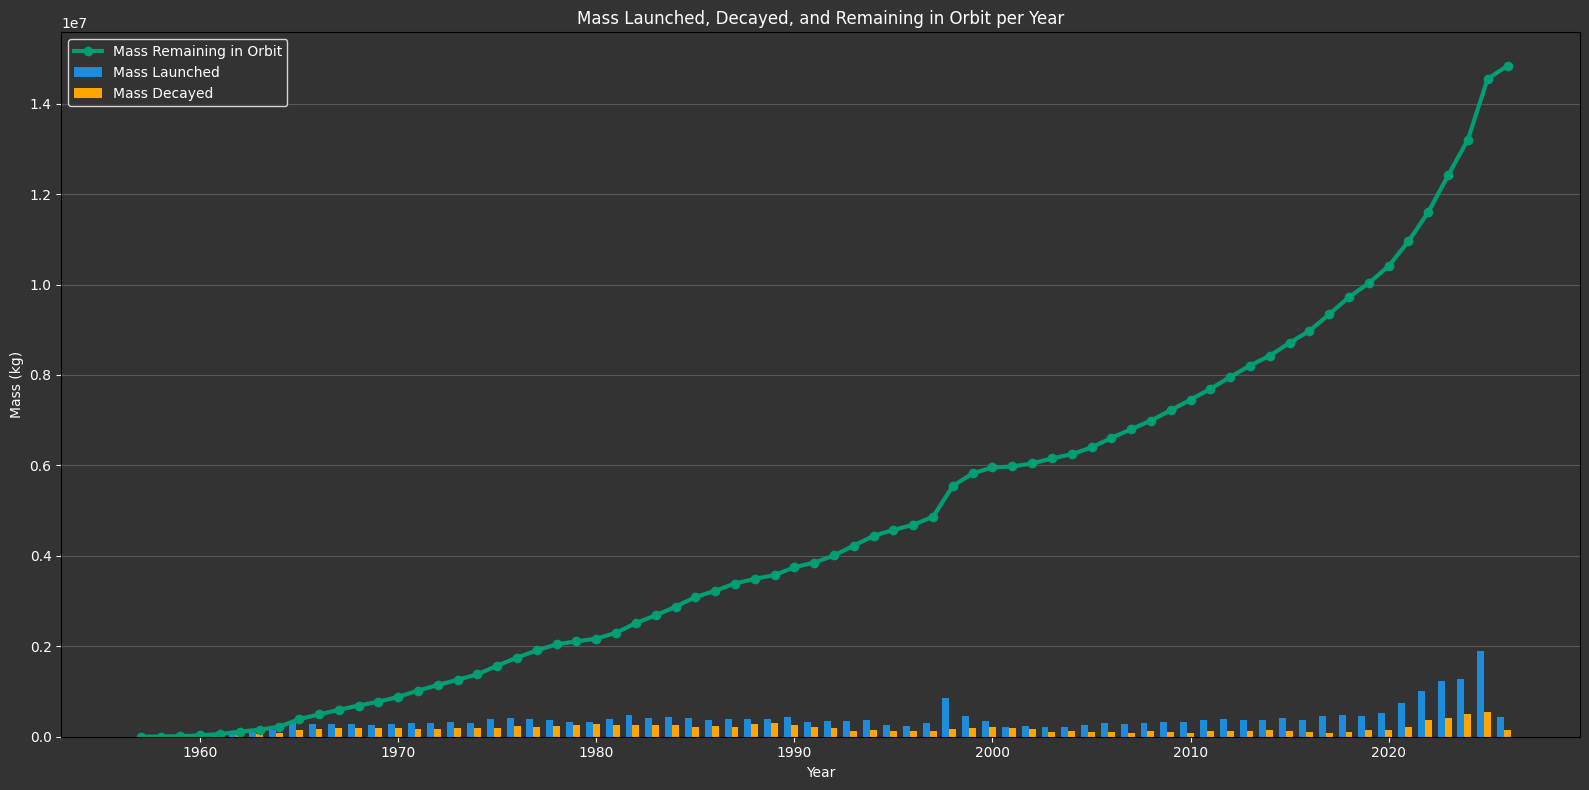

Total mass launched: 27,085,059 kg
Total mass decayed: 12,249,757 kg
Mass remaining in orbit (as of 2026): 14,835,302 kg


In [21]:
# Combined chart: mass launched, mass decayed, and mass remaining by year
if ('proxy_mass_kg' in df_mass_over_time.columns and 
    'in_orbit' in df_mass_over_time.columns and
    'decay_date' in df_mass_over_time.columns):
    
    # Mass launched per year
    mass_by_year = df_mass_over_time.groupby('launch_year')['proxy_mass_kg'].sum().sort_index()
    
    # Mass decayed per year
    df_decayed = df_mass_over_time[df_mass_over_time['in_orbit'] == 0].copy()
    df_decayed['decay_year'] = pd.to_datetime(df_decayed['decay_date'], errors='coerce').dt.year
    decayed_by_year = df_decayed.groupby('decay_year')['proxy_mass_kg'].sum().sort_index()

    # Use the full year range covered by either launches or decays.
    all_years = sorted(set(mass_by_year.index).union(decayed_by_year.index))
    mass_launched = mass_by_year.reindex(all_years, fill_value=0)
    mass_decayed = decayed_by_year.reindex(all_years, fill_value=0)

    # Running totals for remaining mass in orbit
    cumulative_launched = mass_launched.cumsum()
    cumulative_decayed = mass_decayed.cumsum()
    mass_remaining = cumulative_launched - cumulative_decayed

    plt.figure(figsize=(16,8))
    
    width = 0.35

    plt.bar([y - width for y in all_years], mass_launched.values, width=width, label='Mass Launched', color='#1d8cdb')
    plt.bar([y for y in all_years], mass_decayed.values, width=width, label='Mass Decayed', color='orange')
    plt.plot(all_years, mass_remaining.values, label='Mass Remaining in Orbit', color='#009E73', linewidth=3, marker='o')

    plt.title('Mass Launched, Decayed, and Remaining in Orbit per Year')
    plt.xlabel('Year')
    plt.ylabel('Mass (kg)')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/mass_launched_decayed_remaining_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/mass_launched_decayed_remaining_exp.png', bbox_inches='tight', dpi=300)
    plt.show()

    print(f'Total mass launched: {mass_launched.sum():,.0f} kg')
    print(f'Total mass decayed: {mass_decayed.sum():,.0f} kg')
    print(f'Mass remaining in orbit (as of {max(all_years)}): {mass_remaining.iloc[-1]:,.0f} kg')
else:
    print('proxy_mass_kg, in_orbit, or decay_date column not found in mass over time data.')

### Mass Distribution: How mass is spread across orbit class and orbit type

Show how mass is distributed across different orbit classes (LEO, MEO, GEO) and orbit types.

**Method:**
- Query the database for mass, orbit class, and orbit type.
- Group and sum mass by orbit class and orbit type.

**Visuals:**
- A grouped bar chart showing mass distribution by orbit class and orbit type.
- A heatmap alternative showing the same data for comparison.

In [22]:
mass_distribution_query = """
SELECT
    COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
    COALESCE(orbital_data.orbit_type, 'UNKNOWN') AS orbit_type,
    SUM(orbital_data.proxy_mass_kg) AS total_mass_kg,
    COUNT(*) AS object_count
FROM satellites
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE orbital_data.proxy_mass_kg IS NOT NULL
GROUP BY orbit_class, orbit_type
ORDER BY total_mass_kg DESC;
"""

# Run the query and store the result
df_mass_distribution = pd.read_sql_query(mass_distribution_query, orbital_debris_conn)
df_mass_distribution['total_mass_kg'] = pd.to_numeric(df_mass_distribution['total_mass_kg'], errors='coerce')

# Save the query as a parquet file for future use.
df_mass_distribution.to_parquet('../data/clean/results/mass_distribution_exp.parquet', index=False)

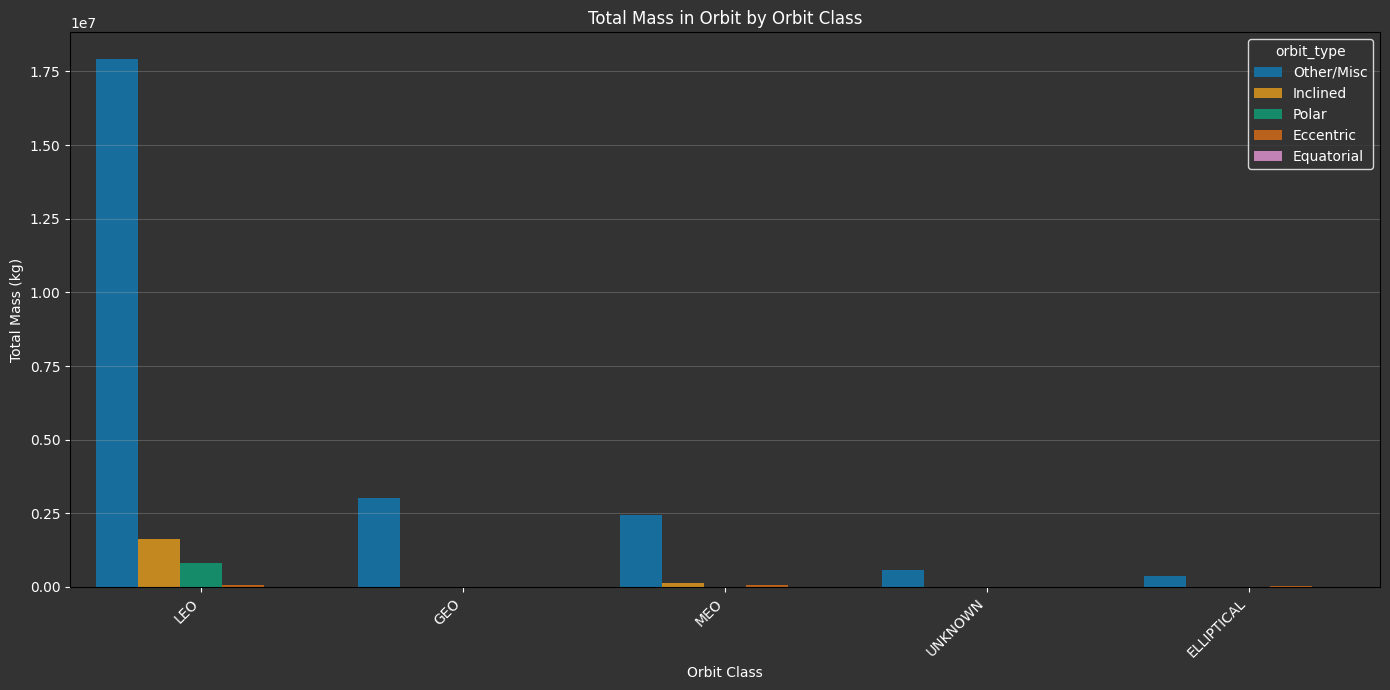

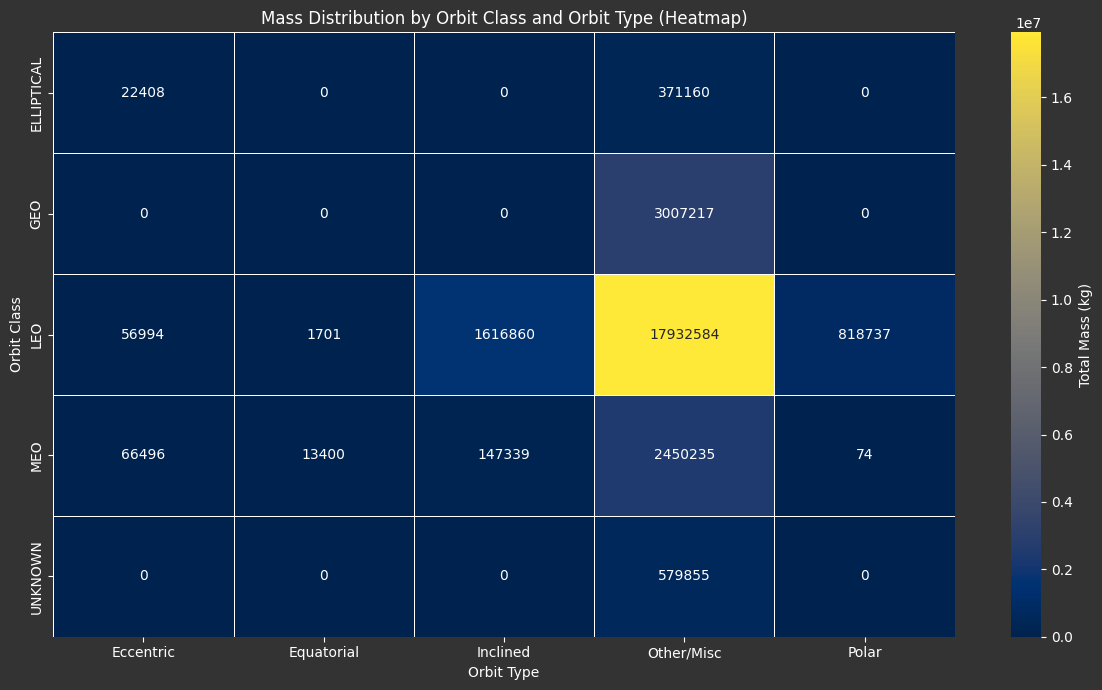

In [23]:
if not df_mass_distribution.empty:
  # Bar chart of total mass by orbit class, colored by orbit type
  plt.figure(figsize=(14, 7))

  sns.barplot(data=df_mass_distribution, x='orbit_class', y='total_mass_kg', hue='orbit_type', palette='colorblind')

  plt.title('Total Mass in Orbit by Orbit Class')
  plt.xlabel('Orbit Class')
  plt.ylabel('Total Mass (kg)')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/mass_by_orbit_class_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/mass_by_orbit_class_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

  # Heatmap alternative view of mass distribution by orbit class and orbit type
  heatmap_df = df_mass_distribution.pivot_table(
      index='orbit_class',
      columns='orbit_type',
      values='total_mass_kg',
      aggfunc='sum',
      fill_value=0
  )

  plt.figure(figsize=(12, 7))
  sns.heatmap(
      heatmap_df,
      cmap='cividis',
      annot=True,
      fmt='.0f',
      linewidths=0.4,
      cbar_kws={'label': 'Total Mass (kg)'}
  )

  plt.title('Mass Distribution by Orbit Class and Orbit Type (Heatmap)')
  plt.xlabel('Orbit Type')
  plt.ylabel('Orbit Class')

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/mass_distribution_heatmap_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/mass_distribution_heatmap_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
else:
  print('No mass distribution data available.')

### Country of Origin: Top countries by number of objects in orbit

Show which countries have the most objects of all types in orbit, based on the country of origin field.  This can help identify which countries are contributing most to orbital congestion and risk.

**Method:**
- Query the database for country of origin and count the number of objects associated with each country.
- Group and sum by country, then show the top countries and roll the rest into `OTHER` for readability.

**Visuals:**
- A bar chart showing the top countries by object count, with `OTHER` highlighted for emphasis

In [24]:
top_countries_by_objects_query = """
SELECT
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_of_origin,
  COUNT(DISTINCT satellites.norad_id) AS object_count
FROM satellites
JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.in_orbit = 1
GROUP BY country_of_origin
ORDER BY object_count DESC;
"""

# Run the query and store the result
df_top_countries = pd.read_sql_query(top_countries_by_objects_query, orbital_debris_conn)

# Save the query as a parquet file for future use.
df_top_countries.to_parquet('../data/clean/results/top_countries_by_objects.parquet', index=False)

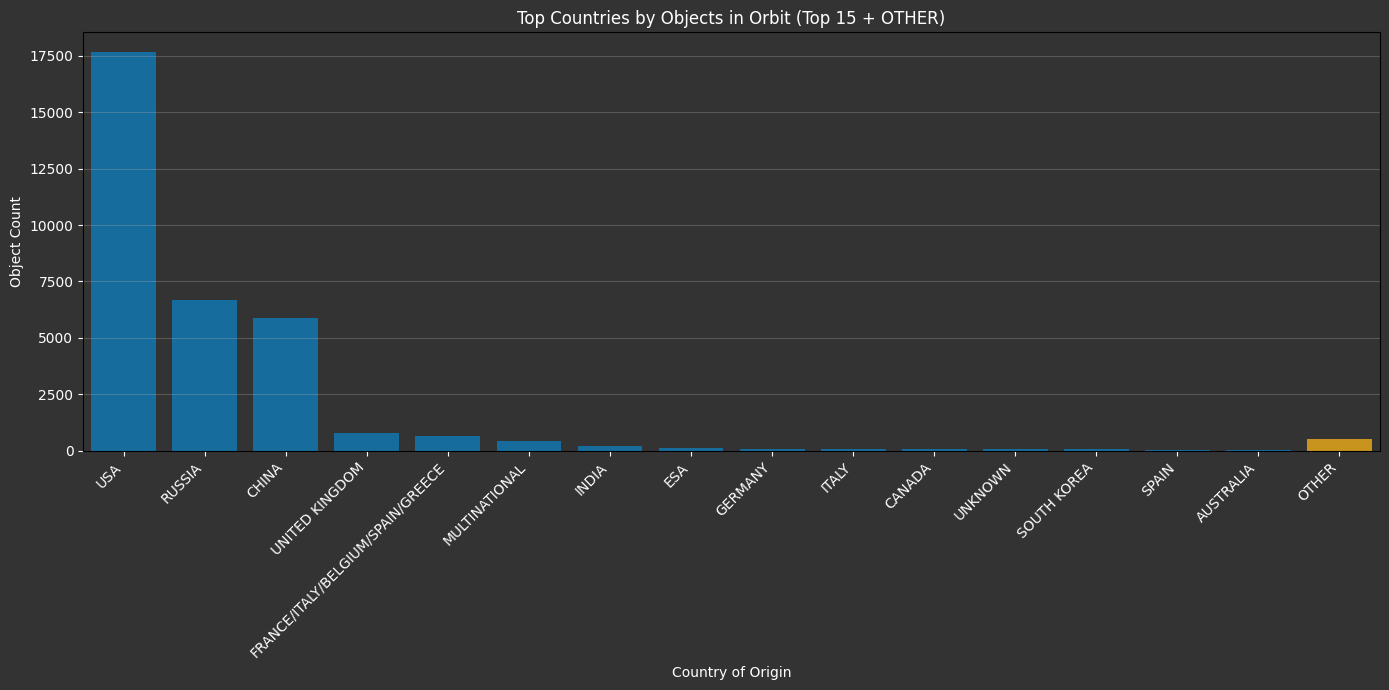

In [25]:
if df_top_countries.empty:
  print('No country-of-origin data available.')
else:
  df_top_countries = df_top_countries.sort_values('object_count', ascending=False).reset_index(drop=True)

  # Keep top N countries and combine the remainder for readability.
  df_top_countries_top = df_top_countries.head(MAX_TOP).copy()
  other_count = df_top_countries.iloc[MAX_TOP:]['object_count'].sum()

  if other_count > 0:
    df_top_countries_top = pd.concat(
        [
            df_top_countries_top,
            pd.DataFrame([{'country_of_origin': 'OTHER', 'object_count': other_count}])
        ],
        ignore_index=True
    )

  # Save both full and rolled-up views.
  df_top_countries_top.to_parquet('../data/clean/results/top_countries_by_objects_top10_other.parquet', index=False)

  # Colorblind-safe emphasis: OTHER in orange, all others in blue.
  colors = ['#0072B2' if country != 'OTHER' else '#E69F00' for country in df_top_countries_top['country_of_origin']]

  plt.figure(figsize=(14, 7))
  sns.barplot(
      data=df_top_countries_top,
      x='country_of_origin',
      y='object_count',
      palette=colors,
      hue='country_of_origin',
      dodge=False,
      legend=False
  )

  plt.title(f'Top Countries by Objects in Orbit (Top {MAX_TOP} + OTHER)')
  plt.xlabel('Country of Origin')
  plt.ylabel('Object Count')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/top_countries_by_objects_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/top_countries_by_objects_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

### Cleanup

In [26]:
orbital_debris_conn.close()